# **Siti Naia Hesti Rachmawati | 24083010047**

# **T04 Machine Learning D**

# **Import Library**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')

# **Load Data**

In [2]:
# @title load data Rossmann
from google.colab import files

print('Upload data Rossmann: train.csv dan store.csv')
uploaded_rossmann = files.upload()

Upload data Rossmann: train.csv dan store.csv


Saving store.csv to store.csv
Saving train.csv to train.csv


In [3]:
# load train.csv Rossmann
ross_train = pd.read_csv('train.csv', low_memory=False)

print('train.csv Rossmann berhasil dimuat!')
print(f'Jumlah baris : {ross_train.shape[0]}')
print(f'Jumlah kolom : {ross_train.shape[1]}')
ross_train.head()

train.csv Rossmann berhasil dimuat!
Jumlah baris : 1017209
Jumlah kolom : 9


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [5]:
# load store.csv Rossmann
ross_store = pd.read_csv('store.csv')

print('store.csv Rossmann berhasil dimuat!')
print(f'Jumlah baris : {ross_store.shape[0]}')
print(f'Jumlah kolom : {ross_store.shape[1]}')
ross_store.head()

store.csv Rossmann berhasil dimuat!
Jumlah baris : 1115
Jumlah kolom : 10


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [6]:
# @title load data Walmart
print('Upload data Walmart: train_walmart.csv, features_walmart.csv, stores_walmart.csv')
uploaded_walmart = files.upload()

Upload data Walmart: train_walmart.csv, features_walmart.csv, stores_walmart.csv


Saving features_walmart.csv to features_walmart.csv
Saving stores_walmart.csv to stores_walmart.csv
Saving train_walmart.csv to train_walmart.csv


In [7]:
# load train_walmart.csv
wal_train = pd.read_csv('train_walmart.csv')

print('train_walmart.csv berhasil dimuat!')
print(f'Jumlah baris : {wal_train.shape[0]}')
print(f'Jumlah kolom : {wal_train.shape[1]}')
wal_train.head()

train_walmart.csv berhasil dimuat!
Jumlah baris : 421570
Jumlah kolom : 5


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [8]:
# load features_walmart.csv
wal_features = pd.read_csv('features_walmart.csv')

print('features_walmart.csv berhasil dimuat!')
print(f'Jumlah baris : {wal_features.shape[0]}')
print(f'Jumlah kolom : {wal_features.shape[1]}')
wal_features.head()

features_walmart.csv berhasil dimuat!
Jumlah baris : 8190
Jumlah kolom : 12


,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


In [9]:
# load stores_walmart.csv
wal_stores   = pd.read_csv('stores_walmart.csv')

print('\nstores_walmart.csv berhasil dimuat!')
print(f'Jumlah baris : {wal_stores.shape[0]}')
print(f'Jumlah kolom : {wal_stores.shape[1]}')
wal_stores.head()


stores_walmart.csv berhasil dimuat!
Jumlah baris : 45
Jumlah kolom : 3


,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


# **Merge Data**

In [10]:
# @title merge data train.csv dan store.csv Rossmann
df_ross = pd.merge(ross_train, ross_store, on='Store', how='inner')

print('Data Rossmann berhasil digabungkan!')
print(f'Jumlah baris : {df_ross.shape[0]}')
print(f'Jumlah kolom : {df_ross.shape[1]}')
df_ross.head()

Data Rossmann berhasil digabungkan!
Jumlah baris : 1017209
Jumlah kolom : 18


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [11]:
# @title merge data ketiga file Walmart
df_wal = wal_train.merge(wal_features, on=['Store', 'Date', 'IsHoliday'], how='left')
df_wal = df_wal.merge(wal_stores, on='Store', how='left')

print('Data Walmart berhasil digabungkan!')
print(f'Jumlah baris : {df_wal.shape[0]}')
print(f'Jumlah kolom : {df_wal.shape[1]}')
df_wal.head()

Data Walmart berhasil digabungkan!
Jumlah baris : 421570
Jumlah kolom : 16


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


# **Informasi Struktur Data**

In [12]:
# @title informasi struktur data Rossmann
df_ross.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   Store                      1017209 non-null  int64  
 1   DayOfWeek                  1017209 non-null  int64  
 2   Date                       1017209 non-null  object 
 3   Sales                      1017209 non-null  int64  
 4   Customers                  1017209 non-null  int64  
 5   Open                       1017209 non-null  int64  
 6   Promo                      1017209 non-null  int64  
 7   StateHoliday               1017209 non-null  object 
 8   SchoolHoliday              1017209 non-null  int64  
 9   StoreType                  1017209 non-null  object 
 10  Assortment                 1017209 non-null  object 
 11  CompetitionDistance        1014567 non-null  float64
 12  CompetitionOpenSinceMonth  693861 non-null   float64
 13  CompetitionO

In [13]:
# @title informasi struktur data Walmart
df_wal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
 5   Temperature   421570 non-null  float64
 6   Fuel_Price    421570 non-null  float64
 7   MarkDown1     150681 non-null  float64
 8   MarkDown2     111248 non-null  float64
 9   MarkDown3     137091 non-null  float64
 10  MarkDown4     134967 non-null  float64
 11  MarkDown5     151432 non-null  float64
 12  CPI           421570 non-null  float64
 13  Unemployment  421570 non-null  float64
 14  Type          421570 non-null  object 
 15  Size          421570 non-null  int64  
dtypes: bool(1), float64(10), int64(3), object(2)
memory usage: 48.6+ MB


# **Statistik Deskriptif**

In [14]:
# @title statistik deskriptif Rossmann
df_ross.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.014567e+06,693861.000000,693861.000000,1.017209e+06,509178.000000,509178.000000
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01,5.430086e+03,7.222866,2008.690228,5.005638e-01,23.269093,2011.752774
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01,7.715324e+03,3.211832,5.992644,4.999999e-01,14.095973,1.662870
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.330000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.890000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000


In [15]:
# @title statistik deskriptif Walmart
df_wal.describe()

,Store,Dept,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Size
count,421570.000000,421570.000000,421570.000000,421570.000000,421570.000000,150681.000000,111248.000000,137091.000000,134967.000000,151432.000000,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123,60.090059,3.361027,7246.420196,3334.628621,1439.421384,3383.168256,4628.975079,171.201947,7.960289,136727.915739
std,12.785297,30.492054,22711.183519,18.447931,0.458515,8291.221345,9475.357325,9623.078290,6292.384031,5962.887455,39.159276,1.863296,60980.583328
min,1.000000,1.000000,-4988.940000,-2.060000,2.472000,0.270000,-265.760000,-29.100000,0.220000,135.160000,126.064000,3.879000,34875.000000
25%,11.000000,18.000000,2079.650000,46.680000,2.933000,2240.270000,41.600000,5.080000,504.220000,1878.440000,132.022667,6.891000,93638.000000
50%,22.000000,37.000000,7612.030000,62.090000,3.452000,5347.450000,192.000000,24.600000,1481.310000,3359.450000,182.318780,7.866000,140167.000000
75%,33.000000,74.000000,20205.852500,74.280000,3.738000,9210.900000,1926.940000,103.990000,3595.040000,5563.800000,212.416993,8.572000,202505.000000
max,45.000000,99.000000,693099.360000,100.140000,4.468000,88646.760000,104519.540000,141630.610000,67474.850000,108519.280000,227.232807,14.313000,219622.000000


# **Identifikasi Variabel**



---

## **Rossmann**

1. Variabel Target (yang akan diprediksi)

> Sales

2. Variabel Fitur (Predictor)

> Store

> DayOfWeek

> Date

> Customers

> Open

> Promo

> StateHoliday

> SchoolHoliday

> StoreType

> Assortment

> CompetitionDistance

> CompetitionOpenSinceMonth

> CompetitionOpenSinceYear

> Promo2

> Promo2SinceWeek

> Promo2SinceYear

> PromoInterval

## **Walmart**

1. Variabel Target(yang akan diprediksi)

> Weekly_Sales

2. Variabel Fitur (Predictor)

> Store

> Dept

> Date

> IsHoliday

> Temperature

> Fuel_Price

> MarkDown1

> MarkDown2

> MarkDown3

> MarkDown4

> MarkDown5

> CPI

> Unemployment

> Type

> Size

# **Missing Value**

In [16]:
# @title cek missing value Rossmann
missing_ross = df_ross.isnull().sum()
persen_ross  = (missing_ross / len(df_ross) * 100).round(2)

hasil_ross = pd.DataFrame({
    'Jumlah Missing' : missing_ross,
    'Persentase (%)'  : persen_ross
})

display(hasil_ross)
print(f'\nTotal missing value: {df_ross.isnull().sum().sum()}')

,Jumlah Missing,Persentase (%)
Store,0,0.00
DayOfWeek,0,0.00
Date,0,0.00
Sales,0,0.00
Customers,0,0.00
Open,0,0.00
Promo,0,0.00
StateHoliday,0,0.00
SchoolHoliday,0,0.00
StoreType,0,0.00



Total missing value: 2173431


In [17]:
# @title cek missing value Walmart
missing_wal = df_wal.isnull().sum()
persen_wal  = (missing_wal / len(df_wal) * 100).round(2)

hasil_wal = pd.DataFrame({
    'Jumlah Missing' : missing_wal,
    'Persentase (%)' : persen_wal
})

display(hasil_wal)
print(f'\nTotal missing value: {df_wal.isnull().sum().sum()}')

,Jumlah Missing,Persentase (%)
Store,0,0.00
Dept,0,0.00
Date,0,0.00
Weekly_Sales,0,0.00
IsHoliday,0,0.00
Temperature,0,0.00
Fuel_Price,0,0.00
MarkDown1,270889,64.26
MarkDown2,310322,73.61
MarkDown3,284479,67.48



Total missing value: 1422431


In [18]:
# @title penanganan missing value Rossmann
kolom_median_ross = ['CompetitionDistance', 'CompetitionOpenSinceMonth',
                     'CompetitionOpenSinceYear']
for col in kolom_median_ross:
    df_ross[col] = df_ross[col].fillna(df_ross[col].median())

df_ross['Promo2SinceWeek']  = df_ross['Promo2SinceWeek'].fillna(0)
df_ross['Promo2SinceYear']  = df_ross['Promo2SinceYear'].fillna(0)
df_ross['PromoInterval']    = df_ross['PromoInterval'].fillna('None')

print('missing value Rossmann setelah ditangani:')
print(df_ross.isnull().sum())

missing value Rossmann setelah ditangani:
Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64


In [19]:
# @title penanganan missing value Walmart
markdowns = ['MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5']
for col in markdowns:
    df_wal[col] = df_wal[col].fillna(df_wal[col].median())

print('missing value Walmart setelah ditangani:')
print(df_wal.isnull().sum())

missing value Walmart setelah ditangani:
Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
Type            0
Size            0
dtype: int64


# **Data Duplikat**

In [20]:
# @title cek dan hapus data duplikat Rossmann
print('CEK DATA DUPLIKAT — ROSSMANN')
print(f'Jumlah duplikat : {df_ross.duplicated().sum()}')

df_ross = df_ross.drop_duplicates()
print(f'Jumlah data setelah hapus duplikat : {len(df_ross)}')

CEK DATA DUPLIKAT — ROSSMANN
Jumlah duplikat : 0
Jumlah data setelah hapus duplikat : 1017209


In [21]:
# @title cek dan hapus data duplikat Walmart
print('CEK DATA DUPLIKAT — WALMART')
print(f'Jumlah duplikat : {df_wal.duplicated().sum()}')

df_wal = df_wal.drop_duplicates()
print(f'Jumlah data setelah hapus duplikat : {len(df_wal)}')

CEK DATA DUPLIKAT — WALMART
Jumlah duplikat : 0
Jumlah data setelah hapus duplikat : 421570


# **Mengubah ke Tipe datetime**

In [22]:
# @title mengubah kolom Date Rossmann menjadi tipe datetime
df_ross['Date'] = pd.to_datetime(df_ross['Date'])

print(f'Tipe data kolom Date sekarang : {df_ross["Date"].dtype}')
print(f'\nContoh nilai Date:')
print(df_ross['Date'].head())

Tipe data kolom Date sekarang : datetime64[ns]

Contoh nilai Date:
0   2015-07-31
1   2015-07-31
2   2015-07-31
3   2015-07-31
4   2015-07-31
Name: Date, dtype: datetime64[ns]


In [23]:
# @title mengubah kolom Date Walmart menjadi tipe datetime
df_wal['Date'] = pd.to_datetime(df_wal['Date'])

print(f'Tipe data kolom Date sekarang : {df_wal["Date"].dtype}')
print(f'\nContoh nilai Date:')
print(df_wal['Date'].head())

Tipe data kolom Date sekarang : datetime64[ns]

Contoh nilai Date:
0   2010-02-05
1   2010-02-12
2   2010-02-19
3   2010-02-26
4   2010-03-05
Name: Date, dtype: datetime64[ns]


# **Fitur Waktu**

In [24]:
# @title membuat fitur baru (waktu) dari kolom Date Rossmann
df_ross['Year']        = df_ross['Date'].dt.year
df_ross['Month']       = df_ross['Date'].dt.month
df_ross['Week']        = df_ross['Date'].dt.isocalendar().week.astype(int)
df_ross['Day_of_Week'] = df_ross['Date'].dt.dayofweek

df_ross[['Date', 'Year', 'Month', 'Week', 'Day_of_Week']].head()

,Date,Year,Month,Week,Day_of_Week
0,2015-07-31,2015,7,31,4
1,2015-07-31,2015,7,31,4
2,2015-07-31,2015,7,31,4
3,2015-07-31,2015,7,31,4
4,2015-07-31,2015,7,31,4


In [25]:
# @title membuat fitur baru (waktu) dari kolom Date Walmart
df_wal['Year']        = df_wal['Date'].dt.year
df_wal['Month']       = df_wal['Date'].dt.month
df_wal['Week']        = df_wal['Date'].dt.isocalendar().week.astype(int)
df_wal['Day_of_Week'] = df_wal['Date'].dt.dayofweek

df_wal[['Date', 'Year', 'Month', 'Week', 'Day_of_Week']].head()

,Date,Year,Month,Week,Day_of_Week
0,2010-02-05,2010,2,5,4
1,2010-02-12,2010,2,6,4
2,2010-02-19,2010,2,7,4
3,2010-02-26,2010,2,8,4
4,2010-03-05,2010,3,9,4


# **Lag Feature**

In [26]:
# @title lag feature Rossmann
df_ross = df_ross.sort_values(['Store', 'Date']).reset_index(drop=True)

df_ross['Lag_1'] = df_ross.groupby('Store')['Sales'].shift(1)
df_ross['Lag_2'] = df_ross.groupby('Store')['Sales'].shift(2)
df_ross['Lag_4'] = df_ross.groupby('Store')['Sales'].shift(4)

df_ross[['Store', 'Date', 'Sales', 'Lag_1', 'Lag_2', 'Lag_4']].head(10)

,Store,Date,Sales,Lag_1,Lag_2,Lag_4
0,1,2013-01-01,0,NaN,NaN,NaN
1,1,2013-01-02,5530,0.0,NaN,NaN
2,1,2013-01-03,4327,5530.0,0.0,NaN
3,1,2013-01-04,4486,4327.0,5530.0,NaN
4,1,2013-01-05,4997,4486.0,4327.0,0.0
5,1,2013-01-06,0,4997.0,4486.0,5530.0
6,1,2013-01-07,7176,0.0,4997.0,4327.0
7,1,2013-01-08,5580,7176.0,0.0,4486.0
8,1,2013-01-09,5471,5580.0,7176.0,4997.0
9,1,2013-01-10,4892,5471.0,5580.0,0.0


In [27]:
# @title lag feature Walmart
df_wal = df_wal.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

df_wal['Lag_1'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
df_wal['Lag_2'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)
df_wal['Lag_4'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)

df_wal[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Lag_1', 'Lag_2', 'Lag_4']].head(10)

,Store,Dept,Date,Weekly_Sales,Lag_1,Lag_2,Lag_4
0,1,1,2010-02-05,24924.50,NaN,NaN,NaN
1,1,1,2010-02-12,46039.49,24924.50,NaN,NaN
2,1,1,2010-02-19,41595.55,46039.49,24924.50,NaN
3,1,1,2010-02-26,19403.54,41595.55,46039.49,NaN
4,1,1,2010-03-05,21827.90,19403.54,41595.55,24924.50
5,1,1,2010-03-12,21043.39,21827.90,19403.54,46039.49
6,1,1,2010-03-19,22136.64,21043.39,21827.90,41595.55
7,1,1,2010-03-26,26229.21,22136.64,21043.39,19403.54
8,1,1,2010-04-02,57258.43,26229.21,22136.64,21827.90
9,1,1,2010-04-09,42960.91,57258.43,26229.21,21043.39


# **Rolling Mean**

In [28]:
# @title rolling mean Rossmann
df_ross['Rolling_Mean_4'] = df_ross.groupby('Store')['Sales'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

df_ross[['Store', 'Date', 'Sales', 'Rolling_Mean_4']].head(10)

,Store,Date,Sales,Rolling_Mean_4
0,1,2013-01-01,0,0.000000
1,1,2013-01-02,5530,2765.000000
2,1,2013-01-03,4327,3285.666667
3,1,2013-01-04,4486,3585.750000
4,1,2013-01-05,4997,4835.000000
5,1,2013-01-06,0,3452.500000
6,1,2013-01-07,7176,4164.750000
7,1,2013-01-08,5580,4438.250000
8,1,2013-01-09,5471,4556.750000
9,1,2013-01-10,4892,5779.750000


In [29]:
# @title rolling mean Walmart
df_wal['Rolling_Mean_4'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

df_wal[['Store', 'Dept', 'Date', 'Weekly_Sales', 'Rolling_Mean_4']].head(10)

,Store,Dept,Date,Weekly_Sales,Rolling_Mean_4
0,1,1,2010-02-05,24924.50,24924.500000
1,1,1,2010-02-12,46039.49,35481.995000
2,1,1,2010-02-19,41595.55,37519.846667
3,1,1,2010-02-26,19403.54,32990.770000
4,1,1,2010-03-05,21827.90,32216.620000
5,1,1,2010-03-12,21043.39,25967.595000
6,1,1,2010-03-19,22136.64,21102.867500
7,1,1,2010-03-26,26229.21,22809.285000
8,1,1,2010-04-02,57258.43,31666.917500
9,1,1,2010-04-09,42960.91,37146.297500


# **Outlier**

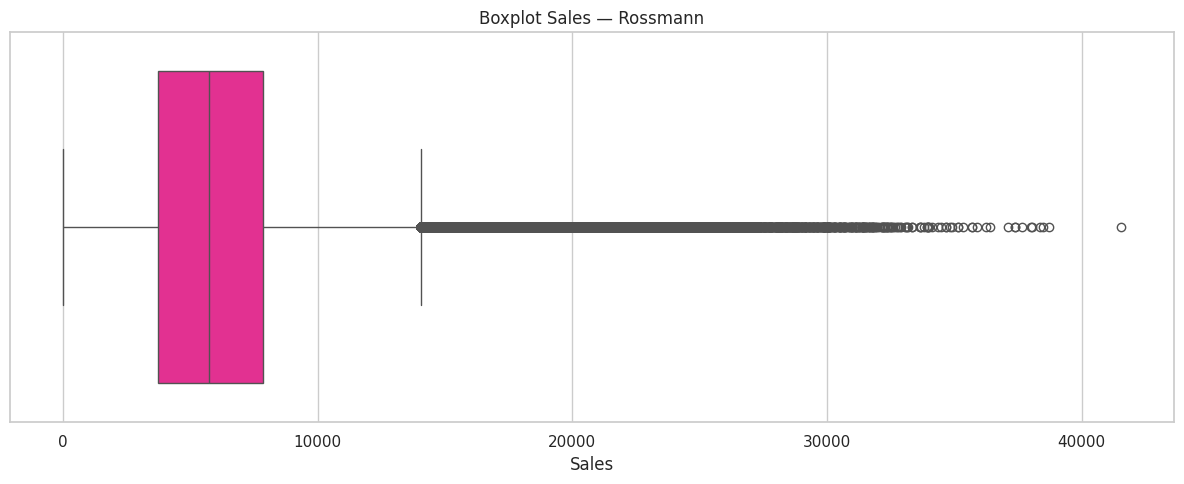

In [30]:
# @title boxplot Rossmann
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_ross['Sales'], color='deeppink')
plt.title('Boxplot Sales — Rossmann')
plt.xlabel('Sales')
plt.tight_layout()
plt.show()

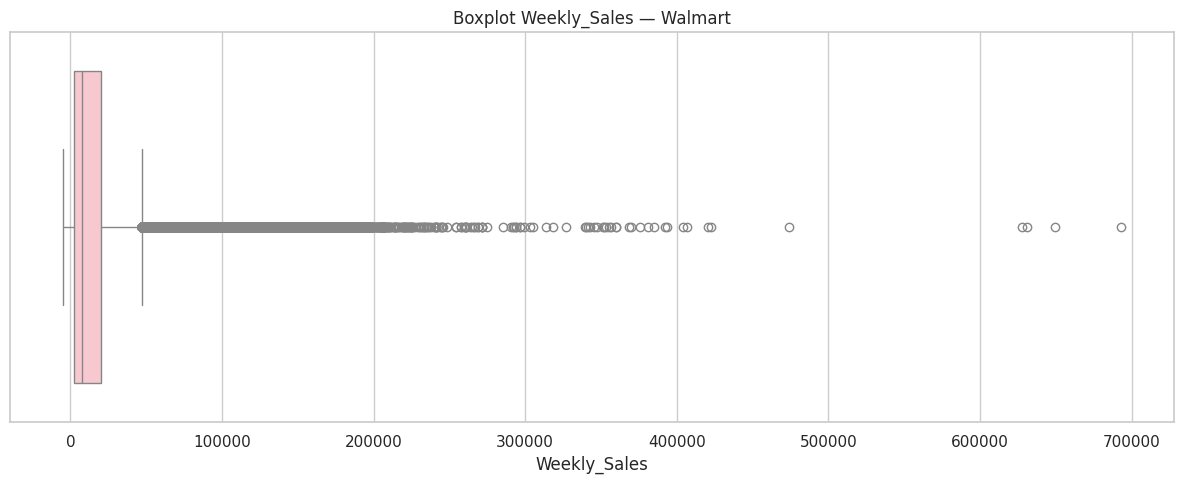

In [34]:
# @title cek boxplot Walmart
plt.figure(figsize=(12, 5))
sns.boxplot(x=df_wal['Weekly_Sales'], color='pink')
plt.title('Boxplot Weekly_Sales — Walmart')
plt.xlabel('Weekly_Sales')
plt.tight_layout()
plt.show()

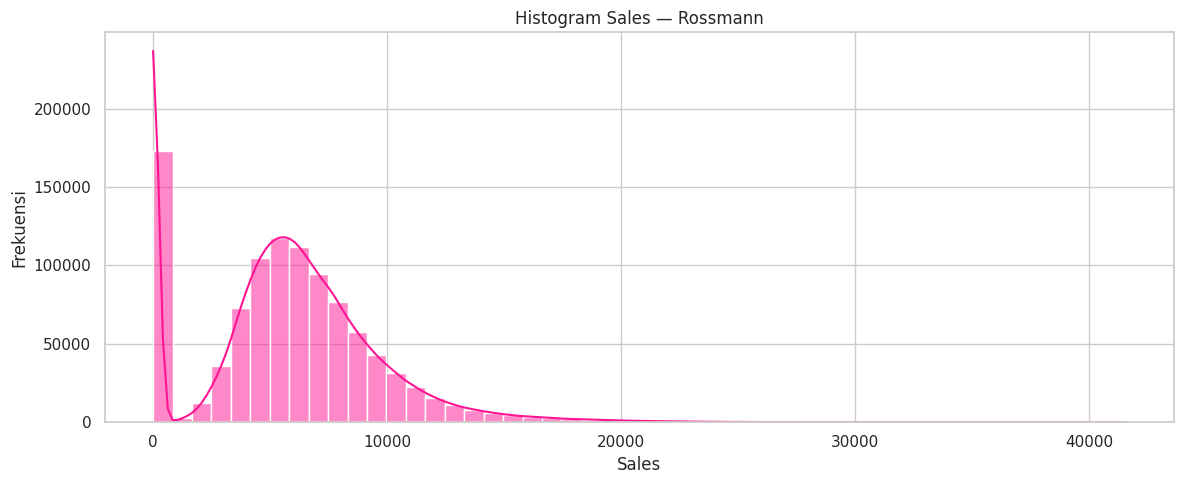

In [35]:
# @title histogram Rossmann
plt.figure(figsize=(12, 5))
sns.histplot(df_ross['Sales'], bins=50, kde=True, color='deeppink')
plt.title('Histogram Sales — Rossmann')
plt.xlabel('Sales')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

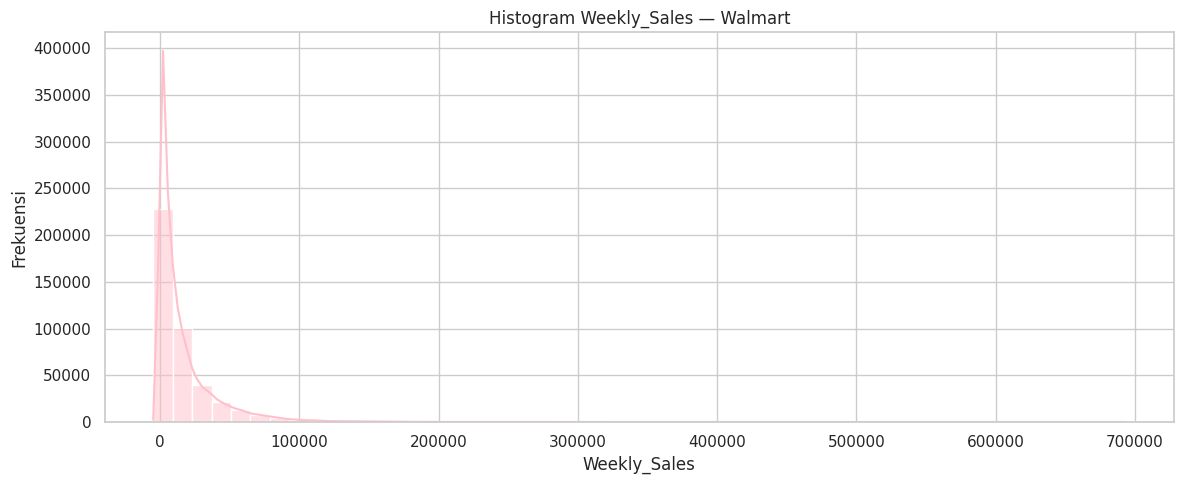

In [36]:
# @title histogram Walmart
plt.figure(figsize=(12, 5))
sns.histplot(df_wal['Weekly_Sales'], bins=50, kde=True, color='pink')
plt.title('Histogram Weekly_Sales — Walmart')
plt.xlabel('Weekly_Sales')
plt.ylabel('Frekuensi')
plt.tight_layout()
plt.show()

In [38]:
# @title penanganan outlier Rossmann dengan IQR
Q1_ross = df_ross['Sales'].quantile(0.25)
Q3_ross = df_ross['Sales'].quantile(0.75)
IQR_ross = Q3_ross - Q1_ross

batas_bawah_ross = Q1_ross - 1.5 * IQR_ross
batas_atas_ross  = Q3_ross + 1.5 * IQR_ross

print('PENANGANAN OUTLIER — ROSSMANN')
print(f'Q1            : {Q1_ross:,.2f}')
print(f'Q3            : {Q3_ross:,.2f}')
print(f'IQR           : {IQR_ross:,.2f}')
print(f'Batas Bawah   : {batas_bawah_ross:,.2f}')
print(f'Batas Atas    : {batas_atas_ross:,.2f}')
print(f'\nJumlah data sebelum : {len(df_ross)}')

df_ross = df_ross[
    (df_ross['Sales'] >= batas_bawah_ross) &
    (df_ross['Sales'] <= batas_atas_ross)
]

print(f'Jumlah data setelah : {len(df_ross)}')
print(f'Outlier dihapus     : {1017209 - len(df_ross)}')

PENANGANAN OUTLIER — ROSSMANN
Q1            : 3,727.00
Q3            : 7,856.00
IQR           : 4,129.00
Batas Bawah   : -2,466.50
Batas Atas    : 14,049.50

Jumlah data sebelum : 1017209
Jumlah data setelah : 990515
Outlier dihapus     : 26694


In [39]:
# @title penanganan outlier Walmart dengan IQR
Q1_wal = df_wal['Weekly_Sales'].quantile(0.25)
Q3_wal = df_wal['Weekly_Sales'].quantile(0.75)
IQR_wal = Q3_wal - Q1_wal

batas_bawah_wal = Q1_wal - 1.5 * IQR_wal
batas_atas_wal  = Q3_wal + 1.5 * IQR_wal

print('PENANGANAN OUTLIER — WALMART')
print(f'Q1            : {Q1_wal:,.2f}')
print(f'Q3            : {Q3_wal:,.2f}')
print(f'IQR           : {IQR_wal:,.2f}')
print(f'Batas Bawah   : {batas_bawah_wal:,.2f}')
print(f'Batas Atas    : {batas_atas_wal:,.2f}')
print(f'\nJumlah data sebelum : {len(df_wal)}')

df_wal = df_wal[
    (df_wal['Weekly_Sales'] >= batas_bawah_wal) &
    (df_wal['Weekly_Sales'] <= batas_atas_wal)
]

print(f'Jumlah data setelah : {len(df_wal)}')
print(f'Outlier dihapus     : {421570 - len(df_wal)}')

PENANGANAN OUTLIER — WALMART
Q1            : 2,079.65
Q3            : 20,205.85
IQR           : 18,126.20
Batas Bawah   : -25,109.65
Batas Atas    : 47,395.16

Jumlah data sebelum : 421570
Jumlah data setelah : 386049
Outlier dihapus     : 35521


# **Normalisasi dan Standardisasi**

In [40]:
# @title normalisasi & standardisasi Rossmann
kolom_numerik_ross = ['CompetitionDistance', 'CompetitionOpenSinceMonth',
                      'CompetitionOpenSinceYear', 'Promo2SinceWeek',
                      'Promo2SinceYear']

minmax_ross   = MinMaxScaler()
standard_ross = StandardScaler()

df_ross_minmax    = df_ross.copy()
df_ross_standard  = df_ross.copy()

df_ross_minmax[kolom_numerik_ross]   = minmax_ross.fit_transform(
    df_ross[kolom_numerik_ross])
df_ross_standard[kolom_numerik_ross] = standard_ross.fit_transform(
    df_ross[kolom_numerik_ross])

print('NORMALISASI & STANDARDISASI — ROSSMANN')
print('\nHasil Min-Max Scaling:')
display(df_ross_minmax[kolom_numerik_ross].head())
print('\nHasil Standardization:')
display(df_ross_standard[kolom_numerik_ross].head())

NORMALISASI & STANDARDISASI — ROSSMANN

Hasil Min-Max Scaling:


,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear
0,0.016482,0.727273,0.93913,0.0,0.0
1,0.016482,0.727273,0.93913,0.0,0.0
2,0.016482,0.727273,0.93913,0.0,0.0
3,0.016482,0.727273,0.93913,0.0,0.0
4,0.016482,0.727273,0.93913,0.0,0.0



Hasil Standardization:


,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2SinceWeek,Promo2SinceYear
0,-0.54428,0.568462,-0.219735,-0.766842,-1.013462
1,-0.54428,0.568462,-0.219735,-0.766842,-1.013462
2,-0.54428,0.568462,-0.219735,-0.766842,-1.013462
3,-0.54428,0.568462,-0.219735,-0.766842,-1.013462
4,-0.54428,0.568462,-0.219735,-0.766842,-1.013462


In [41]:
# @title normalisasi & standardisasi Walmart
kolom_numerik_wal = ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']

minmax_wal   = MinMaxScaler()
standard_wal = StandardScaler()

df_wal_minmax   = df_wal.copy()
df_wal_standard = df_wal.copy()

df_wal_minmax[kolom_numerik_wal]   = minmax_wal.fit_transform(
    df_wal[kolom_numerik_wal])
df_wal_standard[kolom_numerik_wal] = standard_wal.fit_transform(
    df_wal[kolom_numerik_wal])

print('NORMALISASI & STANDARDISASI — WALMART')
print('\nHasil Min-Max Scaling:')
display(df_wal_minmax[kolom_numerik_wal].head())
print('\nHasil Standardization:')
display(df_wal_standard[kolom_numerik_wal].head())

NORMALISASI & STANDARDISASI — WALMART

Hasil Min-Max Scaling:


,Temperature,Fuel_Price,CPI,Unemployment
0,0.434149,0.050100,0.840500,0.405118
1,0.396967,0.038076,0.841941,0.405118
2,0.410861,0.021042,0.842405,0.405118
3,0.476419,0.044589,0.842707,0.405118
4,0.475147,0.076653,0.843008,0.405118



Hasil Standardization:


,Temperature,Fuel_Price,CPI,Unemployment
0,-0.959918,-1.719314,1.016414,0.071421
1,-1.165397,-1.771598,1.020136,0.071421
2,-1.088613,-1.845668,1.021335,0.071421
3,-0.726321,-1.743277,1.022114,0.071421
4,-0.733350,-1.603853,1.022893,0.071421


# **Split Data**

In [42]:
# @title split data Rossmann 80:20 tanpa shuffle
df_ross = df_ross.sort_values('Date').reset_index(drop=True)

split_ross = int(len(df_ross) * 0.8)

train_ross = df_ross.iloc[:split_ross]
test_ross  = df_ross.iloc[split_ross:]

print('SPLIT DATA — ROSSMANN')
print(f'Total data        : {len(df_ross)}')
print(f'Jumlah data train : {len(train_ross)} ({len(train_ross)/len(df_ross)*100:.1f}%)')
print(f'Jumlah data test  : {len(test_ross)} ({len(test_ross)/len(df_ross)*100:.1f}%)')
print(f'\nRentang waktu Training : {train_ross["Date"].min().date()} s/d {train_ross["Date"].max().date()}')
print(f'Rentang waktu Testing  : {test_ross["Date"].min().date()} s/d {test_ross["Date"].max().date()}')

SPLIT DATA — ROSSMANN
Total data        : 990515
Jumlah data train : 792412 (80.0%)
Jumlah data test  : 198103 (20.0%)

Rentang waktu Training : 2013-01-01 s/d 2015-01-30
Rentang waktu Testing  : 2015-01-30 s/d 2015-07-31


In [43]:
# @title split data Walmart 80:20 tanpa shuffle
df_wal = df_wal.sort_values('Date').reset_index(drop=True)

split_wal = int(len(df_wal) * 0.8)

train_wal = df_wal.iloc[:split_wal]
test_wal  = df_wal.iloc[split_wal:]

print('SPLIT DATA — WALMART')
print(f'Total data        : {len(df_wal)}')
print(f'Jumlah data train : {len(train_wal)} ({len(train_wal)/len(df_wal)*100:.1f}%)')
print(f'Jumlah data test  : {len(test_wal)} ({len(test_wal)/len(df_wal)*100:.1f}%)')
print(f'\nRentang waktu Training : {train_wal["Date"].min().date()} s/d {train_wal["Date"].max().date()}')
print(f'Rentang waktu Testing  : {test_wal["Date"].min().date()} s/d {test_wal["Date"].max().date()}')

SPLIT DATA — WALMART
Total data        : 386049
Jumlah data train : 308839 (80.0%)
Jumlah data test  : 77210 (20.0%)

Rentang waktu Training : 2010-02-05 s/d 2012-04-13
Rentang waktu Testing  : 2012-04-13 s/d 2012-10-26


# **Visualisasi**

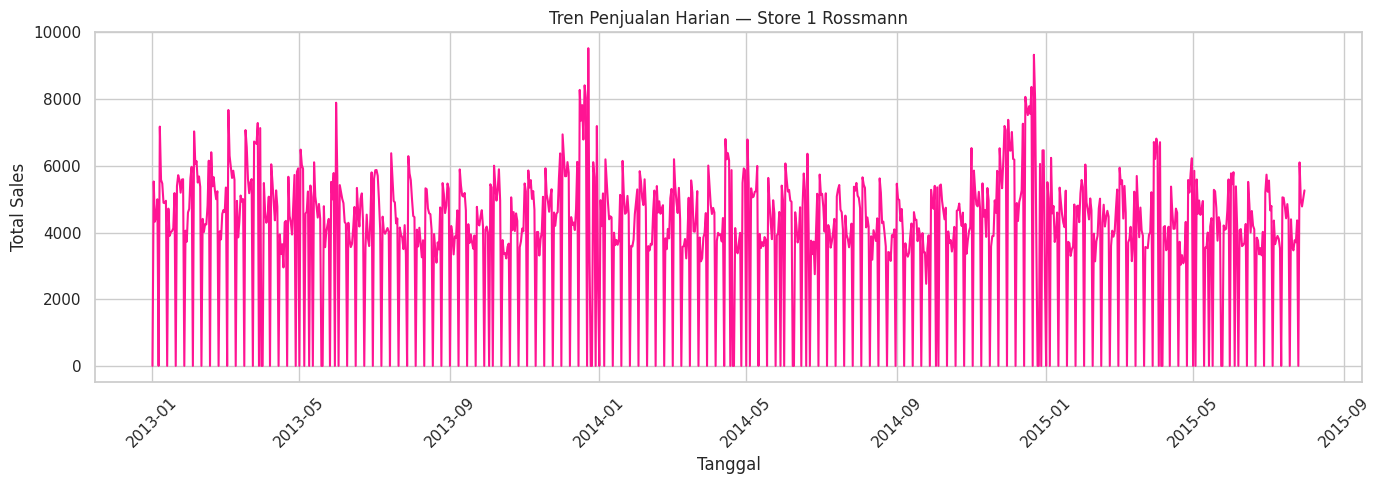

In [44]:
# @title visualisasi tren penjualan Store 1 Rossmann
store1_ross = df_ross[df_ross['Store'] == 1].groupby(
    'Date')['Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(store1_ross['Date'], store1_ross['Sales'],
         color='deeppink', linewidth=1.5)
plt.title('Tren Penjualan Harian — Store 1 Rossmann')
plt.xlabel('Tanggal')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

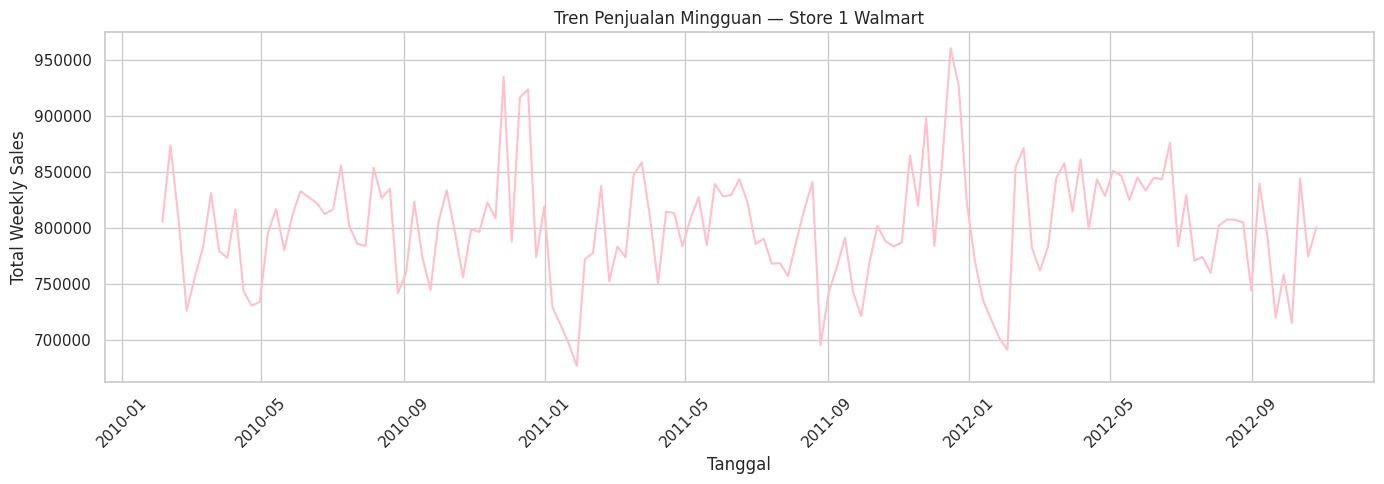

In [45]:
# @title visualisasi tren penjualan Store 1 Walmart
store1_wal = df_wal[df_wal['Store'] == 1].groupby(
    'Date')['Weekly_Sales'].sum().reset_index()

plt.figure(figsize=(14, 5))
plt.plot(store1_wal['Date'], store1_wal['Weekly_Sales'],
         color='pink', linewidth=1.5)
plt.title('Tren Penjualan Mingguan — Store 1 Walmart')
plt.xlabel('Tanggal')
plt.ylabel('Total Weekly Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

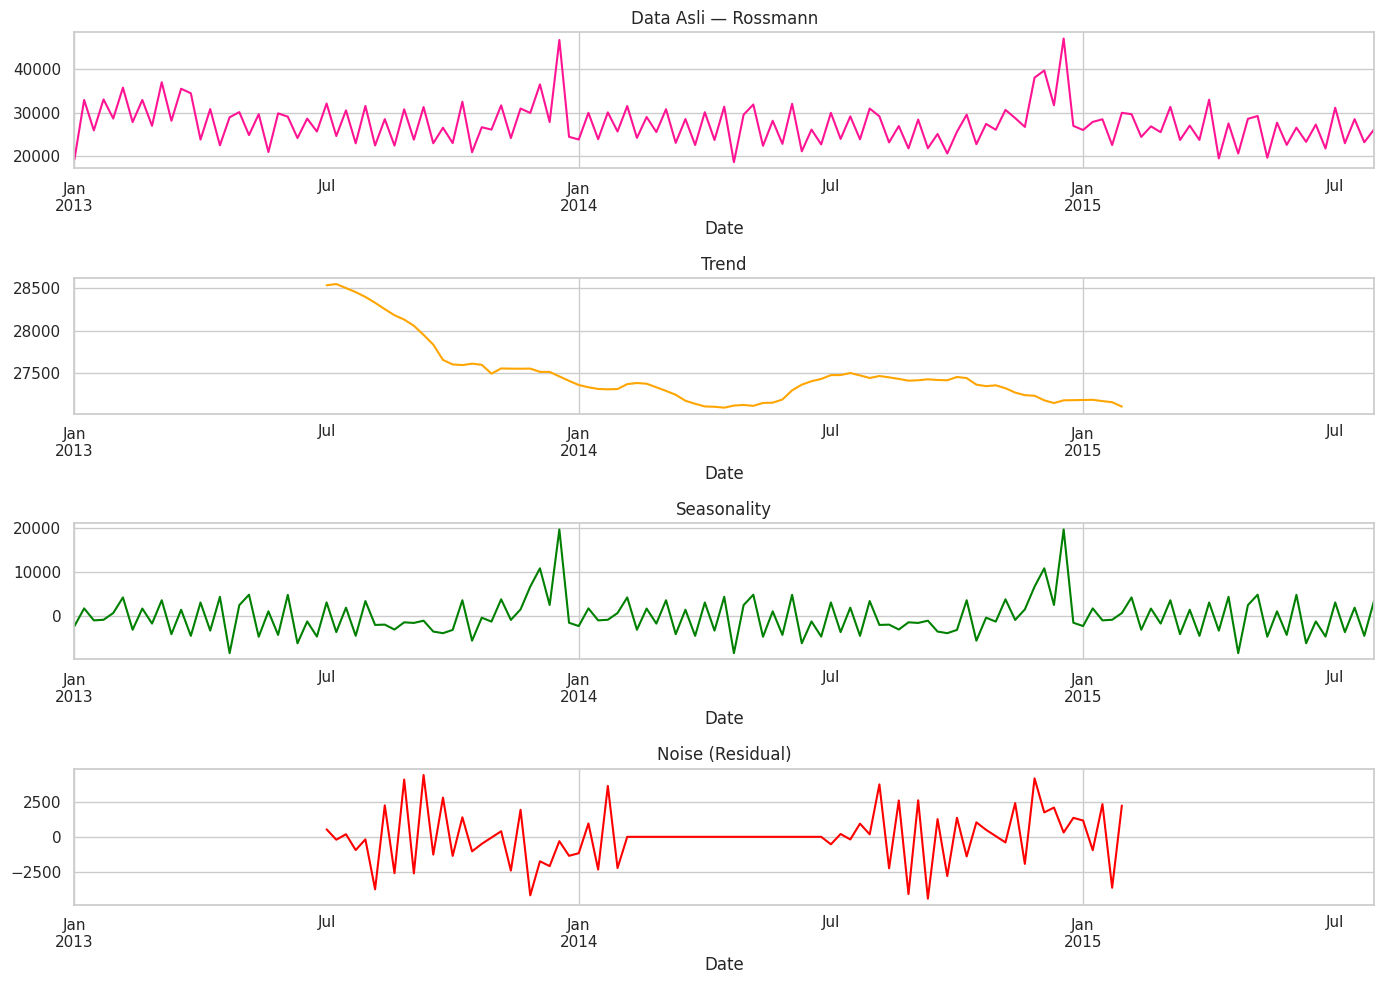

In [46]:
# @title trend, seasonality, dan noise data Rossmann
store1_ross_weekly = df_ross[df_ross['Store'] == 1].copy()
store1_ross_weekly = store1_ross_weekly.set_index(
    'Date')['Sales'].resample('W').sum()

decomp_ross = seasonal_decompose(
    store1_ross_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
store1_ross_weekly.plot(ax=axes[0], title='Data Asli — Rossmann',
                        color='deeppink')
decomp_ross.trend.plot(ax=axes[1], title='Trend', color='orange')
decomp_ross.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomp_ross.resid.plot(ax=axes[3], title='Noise (Residual)', color='red')
plt.tight_layout()
plt.show()

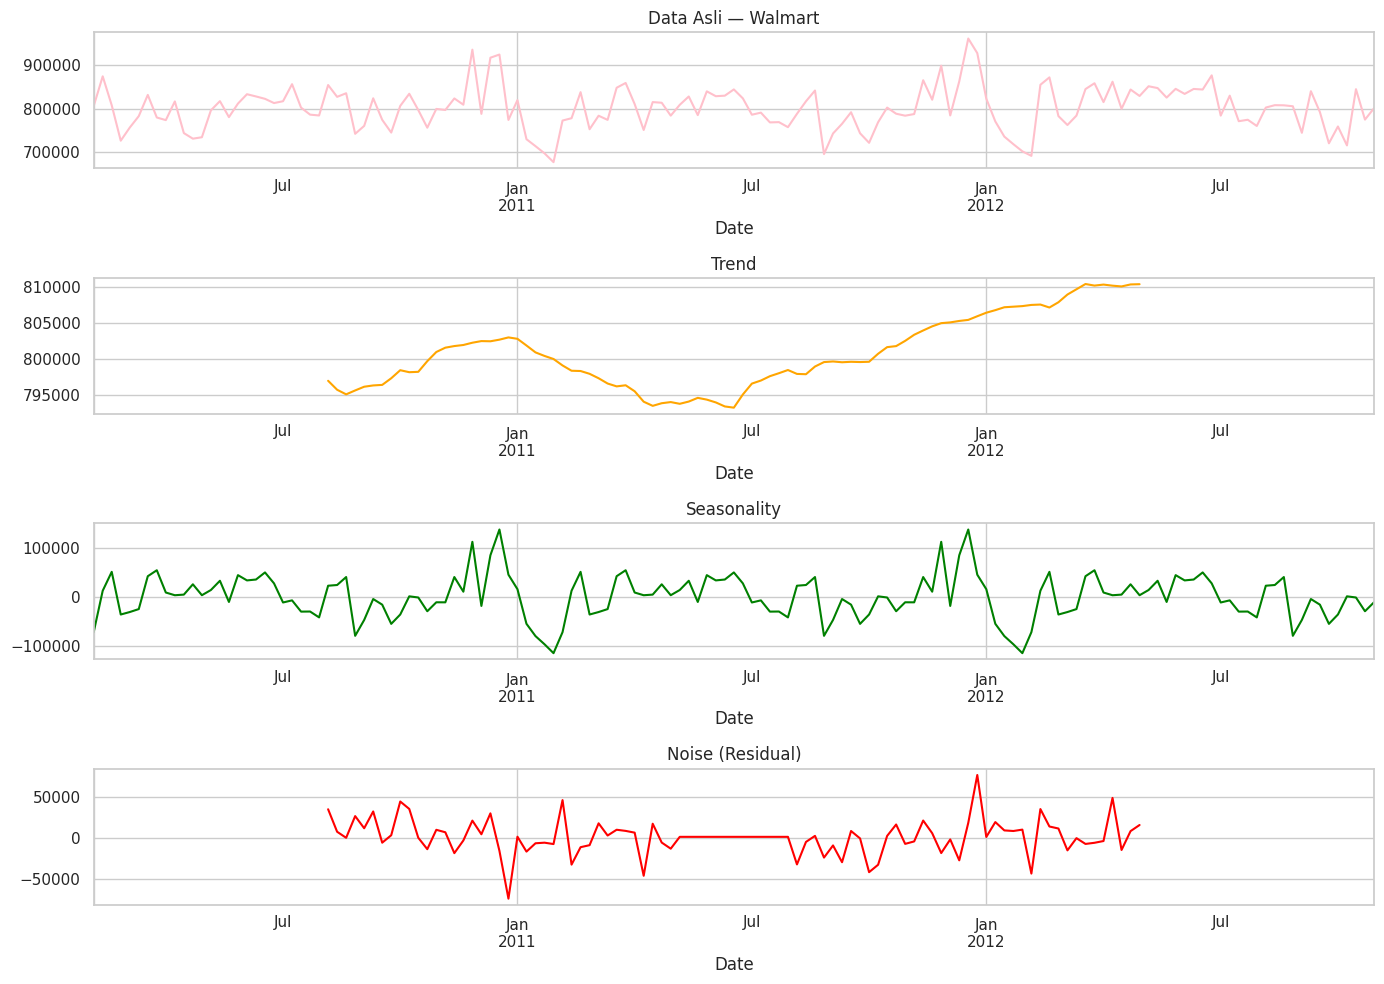

In [47]:
# @title trend, seasonality, dan noise data Walmart
store1_wal_weekly = df_wal[df_wal['Store'] == 1].copy()
store1_wal_weekly = store1_wal_weekly.set_index(
    'Date')['Weekly_Sales'].resample('W').sum()

decomp_wal = seasonal_decompose(
    store1_wal_weekly, model='additive', period=52)

fig, axes = plt.subplots(4, 1, figsize=(14, 10))
store1_wal_weekly.plot(ax=axes[0], title='Data Asli — Walmart',
                       color='pink')
decomp_wal.trend.plot(ax=axes[1], title='Trend', color='orange')
decomp_wal.seasonal.plot(ax=axes[2], title='Seasonality', color='green')
decomp_wal.resid.plot(ax=axes[3], title='Noise (Residual)', color='red')
plt.tight_layout()
plt.show()

# **Resampling**

In [48]:
# @title resample Rossmann dari harian ke mingguan
ross_weekly = df_ross.copy()
ross_weekly = ross_weekly.set_index('Date')

# Agregasi Sales per minggu per Store
ross_weekly = ross_weekly.groupby('Store')['Sales'].resample('W').sum().reset_index()
ross_weekly.columns = ['Store', 'Date', 'Weekly_Sales']

ross_weekly = ross_weekly.sort_values(['Store', 'Date']).reset_index(drop=True)

print('Rossmann berhasil di-resample ke mingguan!')
print(f'Jumlah baris sebelum resample : {len(df_ross)}')
print(f'Jumlah baris setelah resample : {len(ross_weekly)}')
print()
display(ross_weekly.head(10))

Rossmann berhasil di-resample ke mingguan!
Jumlah baris sebelum resample : 990515
Jumlah baris setelah resample : 150395



,Store,Date,Weekly_Sales
0,1,2013-01-06,19340
1,1,2013-01-13,32952
2,1,2013-01-20,25978
3,1,2013-01-27,33071
4,1,2013-02-03,28693
5,1,2013-02-10,35771
6,1,2013-02-17,27880
7,1,2013-02-24,32951
8,1,2013-03-03,27027
9,1,2013-03-10,37016


> Pada tahap pra-pemrosesan data, dilakukan proses transformasi temporal atau resampling untuk mengubah tingkat granularitas data historis penjualan dari skala harian menjadi skala mingguan. Proses ini diaplikasikan secara independen pada setiap entitas toko menggunakan fungsi pengelompokan (groupby), yang kemudian diagregasikan dengan cara menjumlahkan total penjualan (sales) selama periode 7 hari dalam minggu terkait. Transformasi ini berdampak langsung terhadap dimensi dataset Rossmann, di mana total observasi mengalami kompresi yang signifikan dari 990.515 baris data harian menjadi 150.395 baris data mingguan. Penurunan ini dikarenakan setiap tujuh baris observasi harian telah dilebur menjadi satu baris representasi mingguan per toko.

> Berdasarkan tinjauan pada tabel hasil output, khususnya untuk sampel observasi pada Toko 1 di awal periode tahun 2013, data kini menyajikan ringkasan performa yang lebih padat secara time-series. Sebagai contoh, pada minggu pertama yang ditutup pada tanggal 6 Januari 2013, Toko 1 mencatatkan akumulasi penjualan sebesar 19.340. Angka ini kemudian menunjukkan dinamika dengan adanya lonjakan yang cukup signifikan menjadi 32.952 pada minggu berikutnya.

In [49]:
# Verifikasi frekuensi kedua dataset sudah sama
print('VERIFIKASI FREKUENSI DATA')

# Cek interval tanggal Rossmann weekly
ross_interval = ross_weekly.groupby('Store')['Date'].diff().dropna().mode()[0]

# Cek interval tanggal Walmart
wal_interval = df_wal.groupby(['Store', 'Dept'])['Date'].diff().dropna().mode()[0]

print(f'Interval Rossmann (setelah resample) : {ross_interval.days} hari')
print(f'Interval Walmart                     : {wal_interval.days} hari')
print()

# Tabel ringkasan perbandingan frekuensi
ringkasan_frekuensi = pd.DataFrame({
    'Keterangan'         : ['Frekuensi Asal', 'Frekuensi Setelah Penyamaan',
                            'Jumlah Baris Asal', 'Jumlah Baris Final',
                            'Rentang Waktu'],
    'Rossmann'           : ['Harian', 'Mingguan',
                            f'{1017209:,}', f'{len(ross_weekly):,}',
                            '2013 – 2015'],
    'Walmart'            : ['Mingguan', 'Mingguan',
                            f'{421570:,}', f'{len(df_wal):,}',
                            '2010 – 2012']
})

print('TABEL RINGKASAN FREKUENSI DATA')
display(ringkasan_frekuensi)

VERIFIKASI FREKUENSI DATA
Interval Rossmann (setelah resample) : 7 hari
Interval Walmart                     : 7 hari

TABEL RINGKASAN FREKUENSI DATA


,Keterangan,Rossmann,Walmart
0,Frekuensi Asal,Harian,Mingguan
1,Frekuensi Setelah Penyamaan,Mingguan,Mingguan
2,Jumlah Baris Asal,"1,017,209","421,570"
3,Jumlah Baris Final,"150,395","386,049"
4,Rentang Waktu,2013 – 2015,2010 – 2012


# **Model Machine Learning dan Perbandingannya**

In [50]:
# @title fitur engineering untuk Rossmann (weekly)
ross_weekly['Date'] = pd.to_datetime(ross_weekly['Date'])
ross_weekly = ross_weekly.sort_values(['Store', 'Date']).reset_index(drop=True)

ross_weekly['Year']        = ross_weekly['Date'].dt.year
ross_weekly['Month']       = ross_weekly['Date'].dt.month
ross_weekly['Week']        = ross_weekly['Date'].dt.isocalendar().week.astype(int)
ross_weekly['Day_of_Week'] = ross_weekly['Date'].dt.dayofweek

# Lag feature
ross_weekly['Lag_1'] = ross_weekly.groupby('Store')['Weekly_Sales'].shift(1)
ross_weekly['Lag_2'] = ross_weekly.groupby('Store')['Weekly_Sales'].shift(2)
ross_weekly['Lag_4'] = ross_weekly.groupby('Store')['Weekly_Sales'].shift(4)

# Rolling mean
ross_weekly['Rolling_Mean_4'] = ross_weekly.groupby('Store')['Weekly_Sales'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

ross_weekly = ross_weekly.dropna(subset=['Lag_1', 'Lag_2', 'Lag_4'])

print('Fitur ML Rossmann Weekly siap!')
print(f'Jumlah baris : {len(ross_weekly)}')
ross_weekly.head()

Fitur ML Rossmann Weekly siap!
Jumlah baris : 145935


,Store,Date,Weekly_Sales,Year,Month,Week,Day_of_Week,Lag_1,Lag_2,Lag_4,Rolling_Mean_4
4,1,2013-02-03,28693,2013,2,5,6,33071.0,25978.0,19340.0,30173.50
5,1,2013-02-10,35771,2013,2,6,6,28693.0,33071.0,32952.0,30878.25
6,1,2013-02-17,27880,2013,2,7,6,35771.0,28693.0,25978.0,31353.75
7,1,2013-02-24,32951,2013,2,8,6,27880.0,35771.0,33071.0,31323.75
8,1,2013-03-03,27027,2013,3,9,6,32951.0,27880.0,28693.0,30907.25


> Pada tahapan rekayasa fitur (feature engineering), dataset penjualan mingguan Rossmann diperkaya dengan berbagai atribut baru yang secara khusus dirancang untuk mendukung pemodelan Machine Learning berbasis deret waktu (time-series). Proses ini diawali dengan dekomposisi variabel tanggal (Date) menjadi beberapa komponen temporal yang berdiri sendiri, yaitu variabel tahun (Year), bulan (Month), urutan minggu dalam tahun (Week), serta indeks hari (Day_of_Week). Ekstraksi komponen waktu ini merupakan langkah krusial agar model analitik nantinya dapat secara otomatis mempelajari dan mengenali pola musiman (seasonality), siklus bisnis, maupun tren periodik yang secara historis memengaruhi tingkat penjualan suatu toko.

> Selanjutnya, untuk mengakomodasi sifat autokorelasi yang umum ditemukan pada data penjualan, dilakukan pembentukan variabel observasi masa lalu (lag features) dan rata-rata bergerak (rolling mean). Pembentukan variabel Lag_1, Lag_2, dan Lag_4 berfungsi untuk merepresentasikan nilai penjualan pada satu, dua, dan empat minggu sebelumnya secara terpisah untuk tiap-tiap toko. Bersamaan dengan itu, fitur Rolling_Mean_4 dihitung untuk merangkum rata-rata performa penjualan selama jendela waktu empat minggu terakhir. Penambahan variabel-variabel historis ini bertujuan untuk memberikan "memori" kepada model mengenai momentum dan tren pergerakan penjualan terdekat sebelum melakukan prediksi ke depan.

> Sebagai konsekuensi logis dari pembuatan fitur lag tersebut, observasi pada empat minggu pertama untuk setiap toko tidak dapat diproses karena ketiadaan data historis pada minggu-minggu sebelumnya, sehingga menghasilkan nilai kosong (missing values). Oleh karena itu, dilakukan pembersihan data (data cleaning) dengan mengeliminasi baris-baris observasi yang tidak lengkap tersebut. Tindakan ini berdampak pada penyusutan jumlah total observasi, dari sebelumnya di atas 150 ribu baris menjadi 145.935 baris.

In [51]:
# @title fitur engineering untuk Walmart
df_wal = df_wal.sort_values(['Store', 'Dept', 'Date']).reset_index(drop=True)

df_wal['Year']        = df_wal['Date'].dt.year
df_wal['Month']       = df_wal['Date'].dt.month
df_wal['Week']        = df_wal['Date'].dt.isocalendar().week.astype(int)
df_wal['Day_of_Week'] = df_wal['Date'].dt.dayofweek

# Lag feature
df_wal['Lag_1'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(1)
df_wal['Lag_2'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(2)
df_wal['Lag_4'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].shift(4)

# Rolling mean
df_wal['Rolling_Mean_4'] = df_wal.groupby(['Store', 'Dept'])['Weekly_Sales'].transform(
    lambda x: x.rolling(window=4, min_periods=1).mean()
)

# Handle missing values kolom numerik
for col in ['Temperature', 'Fuel_Price', 'CPI', 'Unemployment']:
    if col in df_wal.columns:
        df_wal[col] = df_wal[col].fillna(df_wal[col].median())

df_wal = df_wal.dropna(subset=['Lag_1', 'Lag_2', 'Lag_4'])

print('Fitur ML Walmart siap!')
print(f'Jumlah baris : {len(df_wal)}')
df_wal.head()

Fitur ML Walmart siap!
Jumlah baris : 373480


,Store,Dept,Date,Weekly_Sales,IsHoliday,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,...,Type,Size,Year,Month,Week,Day_of_Week,Lag_1,Lag_2,Lag_4,Rolling_Mean_4
4,1,1,2010-03-05,21827.90,False,46.50,2.625,5347.45,192.0,24.6,...,A,151315,2010,3,9,4,19403.54,41595.55,24924.50,32216.6200
5,1,1,2010-03-12,21043.39,False,57.79,2.667,5347.45,192.0,24.6,...,A,151315,2010,3,10,4,21827.90,19403.54,46039.49,25967.5950
6,1,1,2010-03-19,22136.64,False,54.58,2.720,5347.45,192.0,24.6,...,A,151315,2010,3,11,4,21043.39,21827.90,41595.55,21102.8675
7,1,1,2010-03-26,26229.21,False,51.45,2.732,5347.45,192.0,24.6,...,A,151315,2010,3,12,4,22136.64,21043.39,19403.54,22809.2850
8,1,1,2010-04-09,42960.91,False,65.86,2.770,5347.45,192.0,24.6,...,A,151315,2010,4,14,4,26229.21,22136.64,21827.90,28092.5375


> Sejalan dengan perlakuan pada dataset Rossmann, tahap rekayasa fitur (feature engineering) pada dataset Walmart juga ditujukan untuk memperkaya struktur data guna mendukung pemodelan Machine Learning berbasis deret waktu. Namun, mengingat hierarki data Walmart yang lebih kompleks, proses pengurutan dan pengelompokan (groupby) tidak hanya didasarkan pada entitas toko (Store), melainkan secara spesifik pada kombinasi Toko dan Departemen (Dept). Setelah data diurutkan secara hierarkis, variabel tanggal diurai menjadi beberapa komponen temporal yang independen—meliputi tahun, bulan, minggu, dan hari—agar algoritma mampu mengenali pola musiman (seasonality) secara spesifik hingga ke tingkat departemen di masing-masing lokasi.

> Untuk menangkap tren dan memori historis penjualan, dilakukan pembentukan variabel observasi masa lalu (lag features) yang merekam performa penjualan pada rentang 1, 2, dan 4 minggu sebelumnya, bersamaan dengan kalkulasi rata-rata pergerakan penjualan (rolling mean) selama jendela waktu empat minggu terakhir. Berbeda dengan dataset sebelumnya, pada dataset Walmart ini terdapat penambahan tahapan krusial berupa penanganan nilai kosong (missing values) pada variabel-variabel prediktor eksternal dan makroekonomi, seperti suhu (Temperature), harga bahan bakar (Fuel_Price), indeks harga konsumen (CPI), serta tingkat pengangguran (Unemployment). Kekosongan data pada kolom-kolom numerik tersebut diatasi melalui teknik imputasi menggunakan nilai tengah (median) guna memastikan kelengkapan informasi tanpa merusak distribusi data asli atau rentan terhadap outlier.

> Sebagai implikasi teknis dari pembentukan fitur lag, observasi pada minggu-minggu awal untuk tiap kelompok departemen mengalami ketiadaan riwayat data, sehingga observasi tersebut harus dieliminasi. Pembersihan ini menyisakan total 373.480 baris data yang terverifikasi lengkap.

In [53]:
# @title training dan prediksi model
def train_evaluate(data, fitur, target, label):
    data  = data.sort_values('Date').reset_index(drop=True)
    split = int(len(data) * 0.8)

    X_train = data[fitur].iloc[:split]
    X_test  = data[fitur].iloc[split:]
    y_train = data[target].iloc[:split]
    y_test  = data[target].iloc[split:]

    model  = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    # Filter nilai > 1000 sebelum hitung MAPE
    # untuk menghindari pembagian dengan nilai kecil/negatif
    mask = np.array(y_test) > 1000
    mape = np.mean(np.abs((np.array(y_test)[mask] - y_pred[mask]) /
                           np.array(y_test)[mask])) * 100

    print(f'  HASIL MODEL — {label}')
    print(f'  MAE  : {mae:,.2f}')
    print(f'  MSE  : {mse:,.2f}')
    print(f'  RMSE : {rmse:,.2f}')
    print(f'  MAPE : {mape:.2f}%')

    return model, y_test, y_pred


# Define features for Rossmann model
fitur_ross = [
    'Store',
    'Year',
    'Month',
    'Week',
    'Day_of_Week',
    'Lag_1',
    'Lag_2',
    'Lag_4',
    'Rolling_Mean_4'
]

# Define features for Walmart model
fitur_wal = [
    'Store',
    'Dept',
    'Temperature',
    'Fuel_Price',
    'MarkDown1',
    'MarkDown2',
    'MarkDown3',
    'MarkDown4',
    'MarkDown5',
    'CPI',
    'Unemployment',
    'Type',
    'Size',
    'Year',
    'Month',
    'Week',
    'Day_of_Week',
    'Lag_1',
    'Lag_2',
    'Lag_4',
    'Rolling_Mean_4'
]

# Convert 'Type' column to numerical for Walmart
df_wal_encoded = pd.get_dummies(df_wal, columns=['Type'], drop_first=True)
fitur_wal.remove('Type')
fitur_wal.extend([col for col in df_wal_encoded.columns if 'Type_' in col])
df_wal = df_wal_encoded.copy()


model_ross, y_test_ross, y_pred_ross = train_evaluate(
    ross_weekly, fitur_ross, 'Weekly_Sales', 'ROSSMANN')

model_wal, y_test_wal, y_pred_wal = train_evaluate(
    df_wal, fitur_wal, 'Weekly_Sales', 'WALMART')


  HASIL MODEL — ROSSMANN
  MAE  : 2,582.09
  MSE  : 17,477,225.07
  RMSE : 4,180.58
  MAPE : 7.25%
  HASIL MODEL — WALMART
  MAE  : 671.21
  MSE  : 1,540,424.31
  RMSE : 1,241.14
  MAPE : 8.30%


> Tahap ini melibatkan proses pemodelan prediktif menggunakan algoritma Random Forest Regressor. Mengingat karakteristik data berupa deret waktu (time-series), pembagian dataset menjadi data latih (training set) sebesar 80% dan data uji (testing set) sebesar 20% dilakukan secara ketat berdasarkan urutan kronologis waktu (sequential split), bukan secara acak. Pendekatan ini wajib dilakukan guna mencegah kebocoran informasi dari masa depan ke masa lalu (data leakage). Sebelum data dimasukkan ke dalam model, dilakukan penyesuaian khusus pada dataset Walmart, di mana variabel kategorikal jenis toko (Type) ditransformasi menggunakan teknik One-Hot Encoding agar dapat diproses oleh algoritma matematis. Evaluasi performa model diukur menggunakan empat metrik standar, yaitu Mean Absolute Error (MAE), Mean Squared Error (MSE), Root Mean Squared Error (RMSE), dan Mean Absolute Percentage Error (MAPE). Secara khusus pada perhitungan MAPE, diterapkan sebuah filter batasan uji untuk mengeksklusi nilai penjualan historis di bawah 1.000. Langkah preventif ini diambil untuk menghindari terjadinya distorsi metrik atau galat pembagian tak terhingga (infinity error) yang sering muncul akibat pembagian dengan nilai aktual yang sangat kecil atau mendekati nol.

> Berdasarkan hasil pengujian yang diperoleh, model Random Forest Regressor menunjukkan performa prediksi yang sangat menjanjikan pada kedua dataset.

> Pada data Rossmann, model menghasilkan tingkat kesalahan persentase (MAPE) sebesar 7,25%, dengan nilai eror absolut rata-rata (MAE) di angka 2.582,09 dan RMSE sebesar 4.180,58.

> Sementara itu, pada dataset Walmart yang memiliki struktur hierarki lebih kompleks (berbasis departemen), model mencatatkan tingkat akurasi yang sebanding dengan metrik MAPE sebesar 8,30%. Nilai MAE (671,21) dan RMSE (1.241,14) pada model Walmart tampak secara nominal jauh lebih rendah dibandingkan Rossmann.

> Fenomena ini bukanlah indikator bahwa prediksi Walmart secara mutlak lebih baik, melainkan merupakan representasi dari perbedaan skala data; metrik absolut pada Walmart lebih kecil karena agregasi datanya dipecah hingga ke tingkat departemen, sehingga volume penjualan individu per barisnya memang berskala lebih kecil dibandingkan total penjualan level toko pada Rossmann. Secara keseluruhan, nilai MAPE yang berada di bawah ambang batas 10% untuk kedua skenario ini mengindikasikan bahwa fitur-fitur yang telah direkayasa sebelumnya berhasil memberikan kapabilitas prediktif yang kuat dan model memiliki tingkat akurasi peramalan yang sangat baik.

In [54]:
# @title tabel perbandingan metrik error kedua model
mae_ross  = mean_absolute_error(y_test_ross, y_pred_ross)
mse_ross  = mean_squared_error(y_test_ross, y_pred_ross)
rmse_ross = np.sqrt(mse_ross)
mask_ross = np.array(y_test_ross) > 1000
mape_ross = np.mean(np.abs((np.array(y_test_ross)[mask_ross] - y_pred_ross[mask_ross]) /
                            np.array(y_test_ross)[mask_ross])) * 100

mae_wal   = mean_absolute_error(y_test_wal, y_pred_wal)
mse_wal   = mean_squared_error(y_test_wal, y_pred_wal)
rmse_wal  = np.sqrt(mse_wal)
mask_wal  = np.array(y_test_wal) > 1000
mape_wal  = np.mean(np.abs((np.array(y_test_wal)[mask_wal] - y_pred_wal[mask_wal]) /
                            np.array(y_test_wal)[mask_wal])) * 100

tabel_perbandingan = pd.DataFrame({
    'Metrik'   : ['MAE', 'MSE', 'RMSE', 'MAPE (%)'],
    'Rossmann' : [f'{mae_ross:,.2f}', f'{mse_ross:,.2f}',
                  f'{rmse_ross:,.2f}', f'{mape_ross:.2f}%'],
    'Walmart'  : [f'{mae_wal:,.2f}', f'{mse_wal:,.2f}',
                  f'{rmse_wal:,.2f}', f'{mape_wal:.2f}%'],
    'Model Lebih Baik' : [
        'Rossmann' if mae_ross < mae_wal else 'Walmart',
        'Rossmann' if mse_ross < mse_wal else 'Walmart',
        'Rossmann' if rmse_ross < rmse_wal else 'Walmart',
        'Rossmann' if mape_ross < mape_wal else 'Walmart'
    ]
})

print('TABEL PERBANDINGAN PERFORMA MODEL — ROSSMANN VS WALMART')
print('(Nilai lebih kecil = model lebih baik)')
display(tabel_perbandingan)

TABEL PERBANDINGAN PERFORMA MODEL — ROSSMANN VS WALMART
(Nilai lebih kecil = model lebih baik)


,Metrik,Rossmann,Walmart,Model Lebih Baik
0,MAE,"2,582.09",671.21,Walmart
1,MSE,"17,477,225.07","1,540,424.31",Walmart
2,RMSE,"4,180.58","1,241.14",Walmart
3,MAPE (%),7.25%,8.30%,Rossmann


> Hasil perbandingan secara berdampingan pada tabel semakin mengonfirmasi temuan sebelumnya. Ditinjau dari metrik evaluasi absolut (MAE, MSE, dan RMSE), model Walmart secara konsisten menghasilkan nilai galat yang lebih rendah, menjadikannya lebih unggul pada ketiga parameter tersebut. Namun, pada metrik kesalahan persentase (MAPE), model Rossmann menunjukkan performa yang lebih baik dengan nilai 7,25% dibandingkan Walmart yang berada di angka 8,30%. Sebagai kesimpulan, model Walmart lebih unggul jika dievaluasi berdasarkan skala eror absolut, sedangkan model Rossmann memiliki tingkat akurasi relatif yang sedikit lebih baik dalam merepresentasikan kedekatan hasil prediksi dengan nilai aktualnya

# **Visualisasi 2.0**

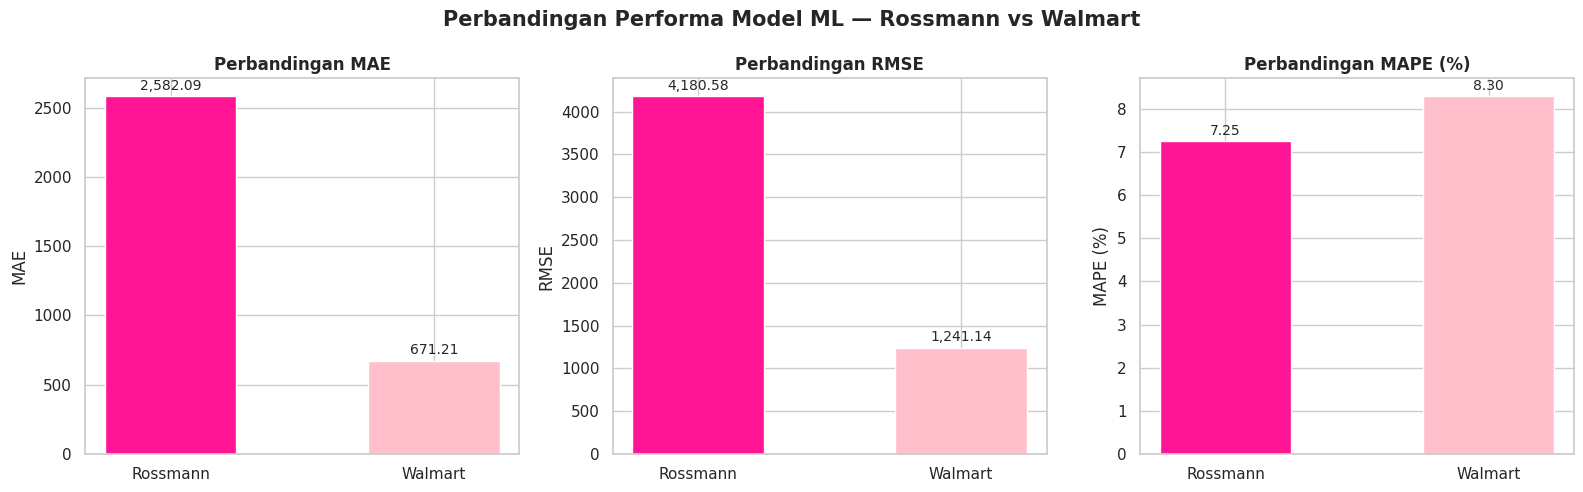

In [59]:
# @title Bar Chart perbandingan MAE, RMSE, MAPE
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrik_labels = ['MAE', 'RMSE', 'MAPE (%)']
ross_values   = [mae_ross, rmse_ross, mape_ross]
wal_values    = [mae_wal, rmse_wal, mape_wal]

for i, (ax, label, rv, wv) in enumerate(
        zip(axes, metrik_labels, ross_values, wal_values)):
    bars = ax.bar(['Rossmann', 'Walmart'], [rv, wv],
                  color=['deeppink', 'pink'], edgecolor='white', width=0.5)
    ax.set_title(f'Perbandingan {label}', fontweight='bold')
    ax.set_ylabel(label)
    for bar, val in zip(bars, [rv, wv]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + max(rv, wv)*0.01,
                f'{val:,.2f}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Perbandingan Performa Model ML — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

> Visualisasi tersebut menyajikan perbandingan grafis mengenai performa model Machine Learning yang diterapkan pada dataset Rossmann dan Walmart, menggunakan 3 metrik evaluasi utama, yaitu Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), dan Mean Absolute Percentage Error (MAPE).

> Pada 2 panel pertama yang menampilkan metrik berbasis nilai absolut (MAE dan RMSE), model Walmart secara visual tampak jauh lebih unggul, ditunjukkan oleh grafik batang berwarna merah muda terang yang posisinya sangat rendah. Walmart mencatatkan nilai MAE sebesar 671,21 dan RMSE sebesar 1.241,14, terpaut cukup jauh dari Rossmann yang mencatatkan nilai MAE sebesar 2.582,09 dan RMSE sebesar 4.180,58. Meski demikian, disparitas yang tajam pada metrik absolut ini bukanlah representasi mutlak dari inferioritas model Rossmann. Perbedaan ini utamanya diakibatkan oleh perbedaan skala atau tingkat granularitas agregasi data; observasi Walmart dipecah hingga ke level departemen sehingga rentang volume penjualannya secara intrinsik lebih kecil, sedangkan data Rossmann diagregasi pada level toko secara keseluruhan yang angkanya secara nominal jauh lebih besar.

> Oleh karena itu, perbandingan performa yang lebih berimbang dan obyektif (apple-to-apple) tergambar secara jelas pada panel ke-3 yang mengevaluasi metrik MAPE. Sebagai metrik yang mengukur kesalahan secara relatif dalam bentuk persentase, MAPE tidak terpengaruh oleh perbedaan skala nominal data. Pada panel ini, grafik batang merah muda tua milik Rossmann menunjukkan nilai 7,25%, sedikit lebih rendah dibandingkan nilai 8,30% milik Walmart. Hal ini mengonfirmasi bahwa secara proporsional, daya prediksi model Rossmann sedikit lebih presisi dalam mengikuti pergerakan nilai penjualan aktual. Secara garis besar, visualisasi ini mempertegas kesimpulan bahwa algoritma Random Forest yang dibangun telah berhasil mencapai tingkat akurasi peramalan yang sangat memuaskan, dibuktikan oleh rasio galat (MAPE) pada kedua model yang berhasil ditekan hingga berada di bawah ambang batas presisi 10%.

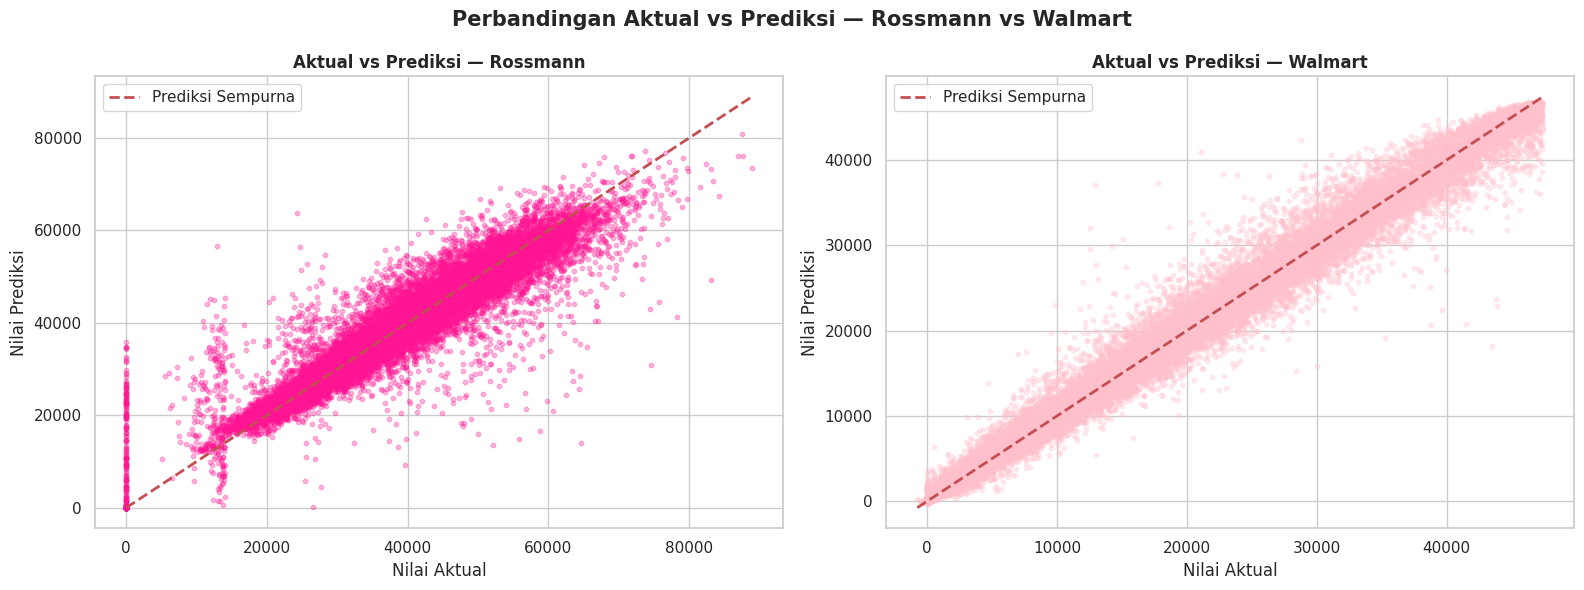

In [60]:
# @title Scatter Plot aktual vs prediksi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Rossmann
axes[0].scatter(y_test_ross, y_pred_ross,
                alpha=0.3, color='deeppink', s=10)
axes[0].plot([np.array(y_test_ross).min(), np.array(y_test_ross).max()],
             [np.array(y_test_ross).min(), np.array(y_test_ross).max()],
             'r--', linewidth=2, label='Prediksi Sempurna')
axes[0].set_title('Aktual vs Prediksi — Rossmann', fontweight='bold')
axes[0].set_xlabel('Nilai Aktual')
axes[0].set_ylabel('Nilai Prediksi')
axes[0].legend()

# Walmart
axes[1].scatter(y_test_wal, y_pred_wal,
                alpha=0.3, color='pink', s=10)
axes[1].plot([np.array(y_test_wal).min(), np.array(y_test_wal).max()],
             [np.array(y_test_wal).min(), np.array(y_test_wal).max()],
             'r--', linewidth=2, label='Prediksi Sempurna')
axes[1].set_title('Aktual vs Prediksi — Walmart', fontweight='bold')
axes[1].set_xlabel('Nilai Aktual')
axes[1].set_ylabel('Nilai Prediksi')
axes[1].legend()

plt.suptitle('Perbandingan Aktual vs Prediksi — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

> Visualisasi scatter plot di atas menyajikan analisis tingkat kesesuaian antara nilai penjualan aktual (direpresentasikan pada sumbu X) dengan nilai prediksi yang dihasilkan oleh model (direpresentasikan pada sumbu Y) untuk dataset Rossmann dan Walmart. Garis diagonal putus-putus pada kedua panel berfungsi sebagai garis referensi prediksi sempurna, yakni kondisi ideal di mana nilai hasil peramalan model bernilai sama persis dengan kondisi nyata di lapangan ($y = x$). Semakin rapat dan simetris titik-titik observasi terdistribusi mengikuti garis diagonal tersebut, semakin tinggi tingkat akurasi dan keandalan model.

> Pada panel sebelah kanan, model prediksi Walmart menunjukkan performa yang sangat impresif. Titik-titik observasi (berwarna merah muda terang) tampak berkerumun dengan sangat rapat dan padat di sepanjang garis referensi diagonal, mulai dari rentang nilai penjualan rendah hingga tinggi. Pola distribusi ini mengonfirmasi secara visual bahwa algoritma Random Forest telah berhasil memetakan kompleksitas data hierarkis Walmart secara konsisten, tanpa menunjukkan adanya penyimpangan (variance) atau anomali yang signifikan. Tingkat kepadatan ini sejalan dengan metrik galat yang rendah pada evaluasi sebelumnya.

> Sebaliknya, tinjauan pada panel sebelah kiri mengungkapkan temuan analitis yang menarik pada model Rossmann. Secara garis besar, mayoritas titik data (berwarna merah muda tua) telah mengikuti tren diagonal dengan baik, memvalidasi tingkat kesalahan persentase (MAPE) yang secara umum rendah. Namun demikian, terdapat sebuah anomali struktural yang sangat mencolok: munculnya garis vertikal berupa tumpukan titik-titik data pada saat nilai aktual bernilai nol (sumbu X = 0). Pada titik-titik observasi tersebut, realitas di lapangan menunjukkan tidak adanya penjualan sama sekali (0), namun model tetap meramalkan angka penjualan yang bervariasi, bahkan hingga menyentuh angka lebih dari 30.000.

> Anomali vertikal pada dataset Rossmann ini memberikan insight krusial terkait perilaku model. Fenomena ini mengindikasikan kegagalan model dalam mengenali hari-hari non-operasional toko. Kemungkinan besar, kondisi aktual nol tersebut merepresentasikan hari di mana toko secara fisik sedang tutup—baik karena hari libur nasional (public holidays), hari Minggu, maupun penutupan operasional lainnya. Karena model hanya mengandalkan fitur riwayat penjualan masa lalu (lag features) dan kalender tanpa diinstruksikan secara eksplisit mengenai status operasional toko, model berasumsi bahwa toko beroperasi secara normal. Temuan evaluatif ini menjadi catatan penting yang menyarankan bahwa iterasi pengembangan model Rossmann di masa mendatang sangat memerlukan penambahan variabel prediktor baru, seperti fitur flagging status toko (Buka/Tutup), guna mencegah munculnya galat prediksi ekstrem pada hari-hari non-operasional.

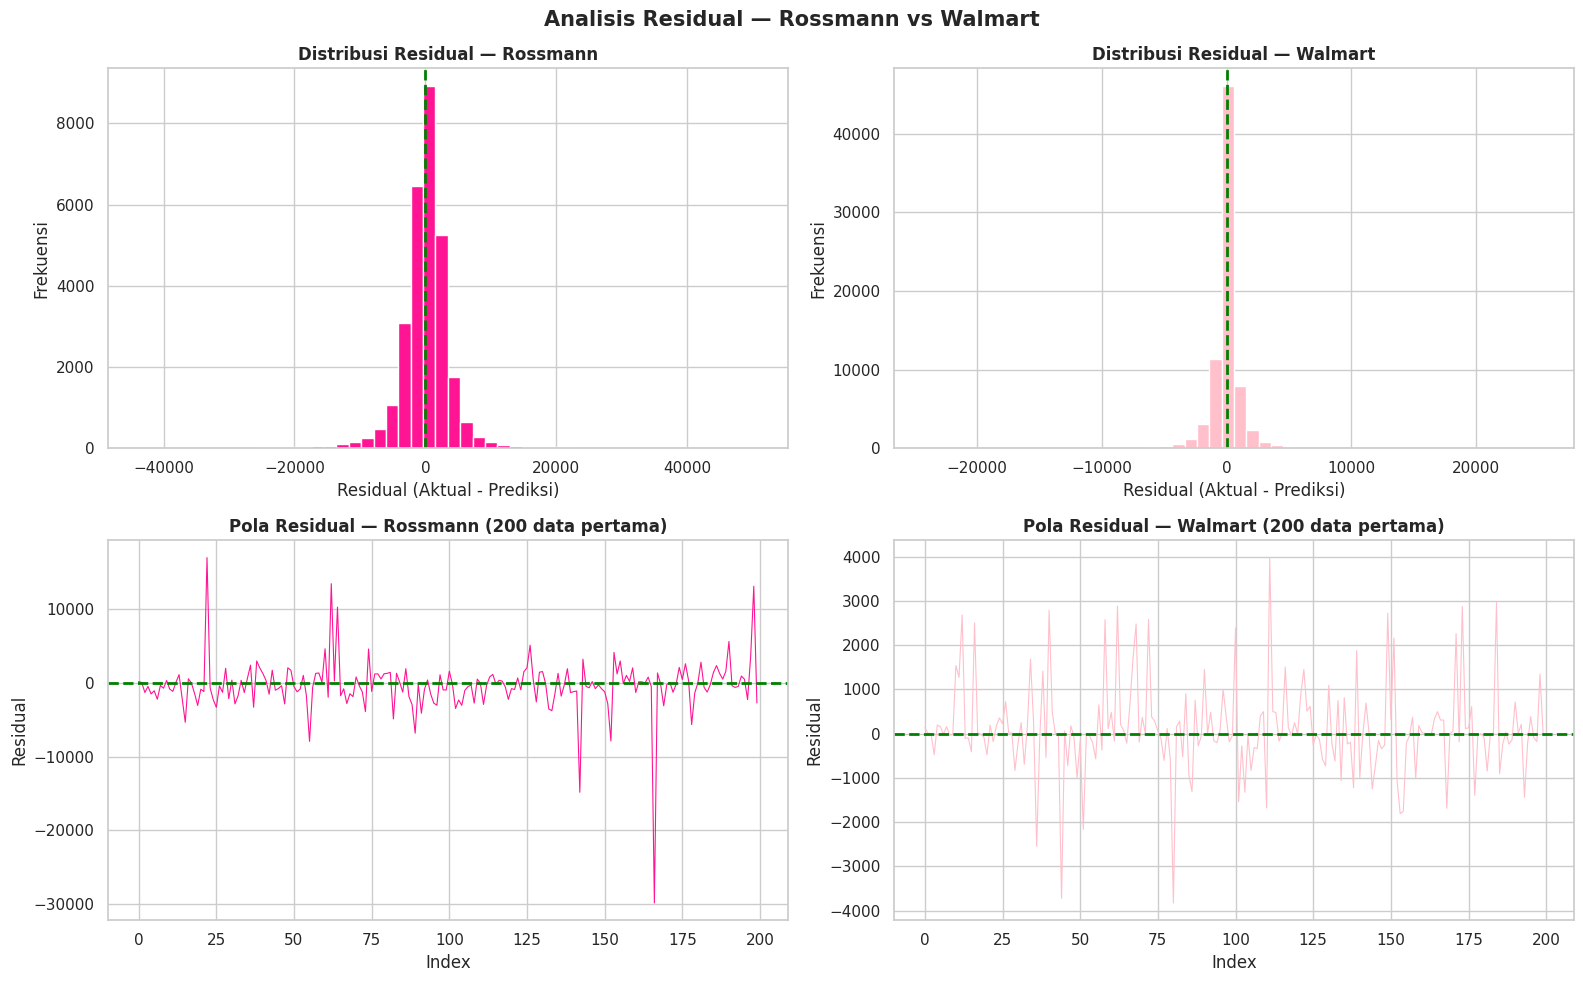


TABEL RINGKASAN RESIDUAL


,Statistik Residual,Rossmann,Walmart
0,Mean Residual,60.93,-40.97
1,Std Residual,"4,180.13","1,240.46"
2,Min Residual,"-43,796.80","-24,185.90"
3,Max Residual,"50,618.72","25,375.75"
4,Median Residual,197.82,-3.38


In [61]:
# @title residual analysis
# Hitung residual
residual_ross = np.array(y_test_ross) - y_pred_ross
residual_wal  = np.array(y_test_wal)  - y_pred_wal

# Visualisasi
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].hist(residual_ross, bins=50, color='deeppink', edgecolor='white')
axes[0,0].axvline(0, color='green', linestyle='--', linewidth=2)
axes[0,0].set_title('Distribusi Residual — Rossmann', fontweight='bold')
axes[0,0].set_xlabel('Residual (Aktual - Prediksi)')
axes[0,0].set_ylabel('Frekuensi')

axes[0,1].hist(residual_wal, bins=50, color='pink', edgecolor='white')
axes[0,1].axvline(0, color='green', linestyle='--', linewidth=2)
axes[0,1].set_title('Distribusi Residual — Walmart', fontweight='bold')
axes[0,1].set_xlabel('Residual (Aktual - Prediksi)')
axes[0,1].set_ylabel('Frekuensi')

axes[1,0].plot(residual_ross[:200], color='deeppink', linewidth=0.8)
axes[1,0].axhline(0, color='green', linestyle='--', linewidth=2)
axes[1,0].set_title('Pola Residual — Rossmann (200 data pertama)', fontweight='bold')
axes[1,0].set_xlabel('Index')
axes[1,0].set_ylabel('Residual')

axes[1,1].plot(residual_wal[:200], color='pink', linewidth=0.8)
axes[1,1].axhline(0, color='green', linestyle='--', linewidth=2)
axes[1,1].set_title('Pola Residual — Walmart (200 data pertama)', fontweight='bold')
axes[1,1].set_xlabel('Index')
axes[1,1].set_ylabel('Residual')

plt.suptitle('Analisis Residual — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel ringkasan residual
tabel_residual = pd.DataFrame({
    'Statistik Residual' : ['Mean Residual', 'Std Residual',
                            'Min Residual', 'Max Residual',
                            'Median Residual'],
    'Rossmann'           : [f'{np.mean(residual_ross):,.2f}',
                            f'{np.std(residual_ross):,.2f}',
                            f'{np.min(residual_ross):,.2f}',
                            f'{np.max(residual_ross):,.2f}',
                            f'{np.median(residual_ross):,.2f}'],
    'Walmart'            : [f'{np.mean(residual_wal):,.2f}',
                            f'{np.std(residual_wal):,.2f}',
                            f'{np.min(residual_wal):,.2f}',
                            f'{np.max(residual_wal):,.2f}',
                            f'{np.median(residual_wal):,.2f}']
})

print('\nTABEL RINGKASAN RESIDUAL')
display(tabel_residual)

> Analisis residual dilakukan untuk mengevaluasi apakah model menyisakan galat (error) yang berpola atau bias secara sistemik. Berdasarkan tabel ringkasan statistik, rata-rata (mean) residual untuk model Rossmann (60,93) dan Walmart (-40,97) sama-sama berada sangat dekat dengan angka nol. Fakta matematis ini dikonfirmasi secara visual oleh panel atas (Distribusi Residual), di mana histogram pada kedua model menunjukkan bentuk lonceng (normal distribution) yang simetris dan terpusat tepat pada garis referensi nol. Karakteristik ini membuktikan bahwa kedua model bersifat objektif dan tidak memiliki bias sistemik; artinya, model tidak memiliki kecenderungan untuk selalu meramalkan nilai yang terlalu tinggi (overpredict) maupun terlalu rendah (underpredict).

> Meskipun distribusi utamanya serupa, panel bawah (Pola Residual 200 data pertama) serta nilai ekstrem pada tabel memperlihatkan perbedaan karakteristik fluktuasi galat di antara keduanya. Model Walmart menunjukkan sebaran galat yang relatif stabil dan acak di sekitar garis nol, dengan standar deviasi yang lebih sempit (1.240,46). Sebaliknya, pada grafik pola residual Rossmann, terlihat adanya lonjakan negatif yang sangat tajam (hingga menyentuh angka -30.000 pada indeks ke-160). Lonjakan ekstrem ini selaras dengan angka Min Residual pada tabel yang mencapai -43.796,80. Sebaran ekstrem pada Rossmann ini kembali memvalidasi temuan anomali pada analisis sebelumnya, yakni ketidakmampuan model dalam memprediksi hari di mana toko sedang tutup operasional (aktual 0, namun prediksi bernilai puluhan ribu), sehingga menghasilkan galat negatif yang sangat besar.


# **Analisis Error**

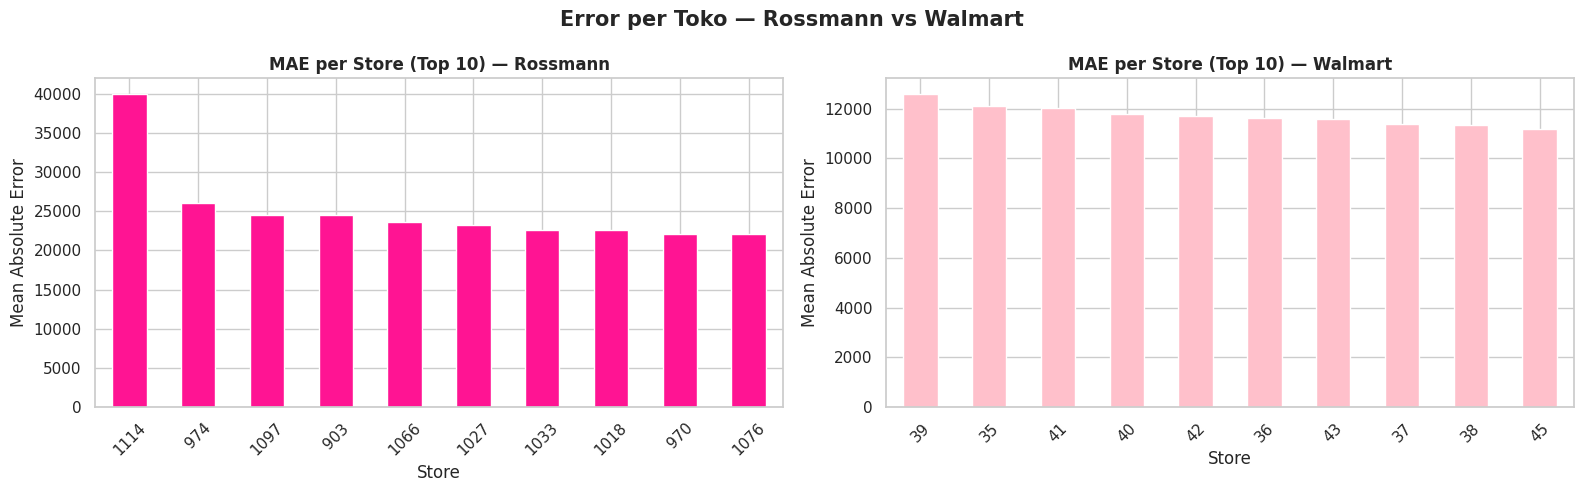


TABEL TOP 5 TOKO DENGAN ERROR TERTINGGI


,Rank,Store Rossmann,MAE Rossmann,Store Walmart,MAE Walmart
0,1,1114,"39,952.27",39,"12,592.76"
1,2,974,"26,048.89",35,"12,127.60"
2,3,1097,"24,538.99",41,"12,043.00"
3,4,903,"24,480.62",40,"11,796.21"
4,5,1066,"23,600.85",42,"11,724.86"


In [62]:
# @title error per Store
ross_test_df        = ross_weekly.iloc[int(len(ross_weekly)*0.8):].copy()
ross_test_df        = ross_test_df.reset_index(drop=True)
ross_test_df['Pred']      = y_pred_ross
ross_test_df['Error_Abs'] = np.abs(ross_test_df['Weekly_Sales'] -
                                    ross_test_df['Pred'])

wal_test_df         = df_wal.iloc[int(len(df_wal)*0.8):].copy()
wal_test_df         = wal_test_df.reset_index(drop=True)
wal_test_df['Pred']       = y_pred_wal
wal_test_df['Error_Abs']  = np.abs(wal_test_df['Weekly_Sales'] -
                                    wal_test_df['Pred'])

error_store_ross = ross_test_df.groupby('Store')['Error_Abs'].mean().sort_values(
    ascending=False).head(10)
error_store_wal  = wal_test_df.groupby('Store')['Error_Abs'].mean().sort_values(
    ascending=False).head(10)

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

error_store_ross.plot(kind='bar', ax=axes[0], color='deeppink')
axes[0].set_title('MAE per Store (Top 10) — Rossmann', fontweight='bold')
axes[0].set_xlabel('Store')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].tick_params(axis='x', rotation=45)

error_store_wal.plot(kind='bar', ax=axes[1], color='pink')
axes[1].set_title('MAE per Store (Top 10) — Walmart', fontweight='bold')
axes[1].set_xlabel('Store')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Error per Toko — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel top 5 toko dengan error tertinggi
tabel_error_toko = pd.DataFrame({
    'Rank'             : [1, 2, 3, 4, 5],
    'Store Rossmann'   : error_store_ross.head(5).index.tolist(),
    'MAE Rossmann'     : [f'{v:,.2f}' for v in error_store_ross.head(5).values],
    'Store Walmart'    : error_store_wal.head(5).index.tolist(),
    'MAE Walmart'      : [f'{v:,.2f}' for v in error_store_wal.head(5).values]
})

print('\nTABEL TOP 5 TOKO DENGAN ERROR TERTINGGI')
display(tabel_error_toko)

> Analisis granular pada tingkat entitas toko (store-level evaluation) dilakukan untuk mengidentifikasi lokasi-lokasi spesifik yang memiliki tingkat kesulitan prediksi tertinggi atau menyumbang galat (error) terbesar terhadap model. Berdasarkan visualisasi diagram batang dan tabel ringkasan Top 5, metrik Mean Absolute Error (MAE) digunakan untuk memetakan distribusi kesalahan tersebut.

> Pada panel sebelah kanan (dataset Walmart), distribusi galat pada 10 toko dengan error tertinggi tampak relatif seragam dan stabil. Toko 39 memimpin dengan nilai MAE sebesar 12.592,76, yang kemudian diikuti secara bertahap oleh Toko 35, 41, dan seterusnya dengan selisih penurunan yang sangat tipis (berada di rentang 11.000 hingga 12.000). Karakteristik grafik yang landai ini mengindikasikan bahwa ketidakakuratan prediksi pada model Walmart bersifat cukup merata di antara toko-toko tersulitnya. Tidak ada satu toko spesifik yang performa prediksinya merusak metrik evaluasi secara keseluruhan.

> Sebaliknya, temuan anomali yang sangat mencolok teridentifikasi pada panel sebelah kiri (dataset Rossmann). Terjadi ketimpangan (skewness) yang sangat ekstrem pada Toko 1114, yang mencatatkan nilai MAE sebesar 39.952,27. Angka ini terpaut sangat jauh (hampir dua kali lipat) dibandingkan toko di urutan kedua, yakni Toko 974, yang memiliki MAE sebesar 26.048,89. Lonjakan galat yang berdiri sendiri (outlier) ini memberikan insight operasional yang sangat penting.

> Tingginya galat eksklusif pada Toko 1114 mengindikasikan bahwa toko tersebut memiliki pola penjualan atau karakteristik operasional yang sangat unik dan menyimpang dari tren umum mayoritas toko Rossmann lainnya. Hal ini bisa disebabkan oleh berbagai faktor eksternal yang belum direpresentasikan ke dalam fitur Machine Learning, seperti adanya renovasi toko jangka panjang, kejadian atau promosi lokal yang sangat masif, atau perubahan demografi pelanggan di sekitar lokasi tersebut.

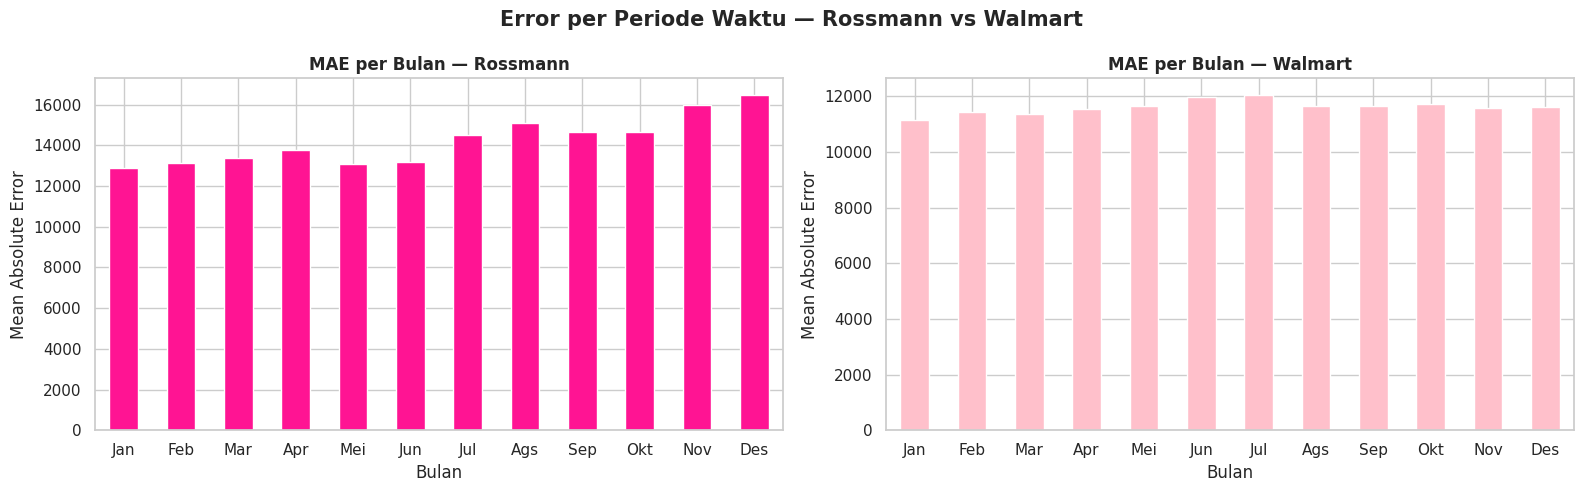


TABEL ERROR PER BULAN


,Bulan,Rossmann,Walmart
0,Jan,"12,889.20","11,143.12"
1,Feb,"13,143.62","11,443.44"
2,Mar,"13,368.56","11,372.69"
3,Apr,"13,769.46","11,546.80"
4,Mei,"13,090.39","11,645.65"
5,Jun,"13,210.11","11,953.16"
6,Jul,"14,518.66","12,039.11"
7,Ags,"15,106.41","11,658.31"
8,Sep,"14,669.30","11,646.50"
9,Okt,"14,670.58","11,714.93"


In [64]:
# @title error per bulan
ross_test_df['Month'] = pd.to_datetime(ross_test_df['Date']).dt.month
wal_test_df['Month']  = pd.to_datetime(wal_test_df['Date']).dt.month

error_bulan_ross = ross_test_df.groupby('Month')['Error_Abs'].mean()
error_bulan_wal  = wal_test_df.groupby('Month')['Error_Abs'].mean()

nama_bulan = {1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr', 5:'Mei', 6:'Jun',
              7:'Jul', 8:'Ags', 9:'Sep', 10:'Okt', 11:'Nov', 12:'Des'}

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

error_bulan_ross.plot(kind='bar', ax=axes[0], color='deeppink')
axes[0].set_title('MAE per Bulan — Rossmann', fontweight='bold')
axes[0].set_xlabel('Bulan')
axes[0].set_ylabel('Mean Absolute Error')
axes[0].set_xticklabels([nama_bulan.get(i, i) for i in
                          error_bulan_ross.index], rotation=0)

error_bulan_wal.plot(kind='bar', ax=axes[1], color='pink')
axes[1].set_title('MAE per Bulan — Walmart', fontweight='bold')
axes[1].set_xlabel('Bulan')
axes[1].set_ylabel('Mean Absolute Error')
axes[1].set_xticklabels([nama_bulan.get(i, i) for i in
                          error_bulan_wal.index], rotation=0)

plt.suptitle('Error per Periode Waktu — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel error per bulan
bulan_index = sorted(set(error_bulan_ross.index) | set(error_bulan_wal.index))

tabel_error_bulan = pd.DataFrame({
    'Bulan'    : [nama_bulan.get(b, b) for b in bulan_index],
    'Rossmann' : [f'{error_bulan_ross.get(b, float("nan")):,.2f}'
                  for b in bulan_index],
    'Walmart'  : [f'{error_bulan_wal.get(b, float("nan")):,.2f}'
                  for b in bulan_index]
})

print('\nTABEL ERROR PER BULAN')
display(tabel_error_bulan)

> Untuk mengevaluasi konsistensi performa model secara temporal, dilakukan analisis distribusi galat (Mean Absolute Error / MAE) berdasarkan periode bulan kalender (Januari hingga Desember). Evaluasi ini bertujuan untuk mengidentifikasi apakah model memiliki kelemahan peramalan pada musim-musim tertentu (seasonality) atau mampu mempertahankan tingkat akurasinya sepanjang tahun.

> Berdasarkan visualisasi diagram batang dan tabel ringkasan di atas, terlihat perbedaan karakteristik fluktuasi galat yang sangat kontras antara kedua dataset. Pada model Walmart (panel kanan/warna merah muda), tingkat kesalahan prediksi tampak sangat stabil dan merata di setiap bulannya. Nilai MAE berfluktuasi tipis di rentang 11.139,18 (Januari) hingga puncak tertingginya di angka 12.026,86 (Juli). Distribusi yang nyaris mendatar (flat) ini mengindikasikan bahwa fitur-fitur yang dimasukkan ke dalam algoritma Random Forest telah sangat sukses dalam menangkap dan memodelkan pola musiman penjualan Walmart. Model tidak mengalami "kaget" atau penurunan performa yang drastis pada bulan apa pun.

> Sebaliknya, pada model Rossmann (panel kiri/warna deep pink), terlihat adanya tren peningkatan galat yang cukup linier seiring berjalannya waktu menuju akhir tahun. Pada kuartal pertama hingga pertengahan tahun (Januari - Juni), model berkinerja cukup baik dengan MAE yang tertahan di kisaran 12.000 hingga 13.000. Namun, memasuki kuartal keempat, terjadi lonjakan galat yang signifikan, memuncak pada bulan November (15.984,12) dan Desember (16.474,55).

> Tingginya tingkat kesalahan prediksi Rossmann di akhir tahun ini sangat berkorelasi dengan dinamika musim liburan (holiday season), seperti persiapan Natal dan Tahun Baru. Pada periode ini, perilaku konsumen umumnya berubah drastis karena adanya promosi besar-besaran atau pola belanja diskon akhir tahun yang fluktuatif. Tingginya angka galat ini memberikan insight bahwa model saat ini masih kesulitan untuk mengimbangi variansi ekstrem dari lonjakan penjualan akhir tahun. Sebagai rekomendasi untuk pengembangan lebih lanjut, performa model Rossmann berpotensi ditingkatkan dengan menambahkan fitur spesifik terkait kalender promosi liburan (holiday promo flags) agar algoritma dapat lebih peka terhadap anomali lonjakan transaksi di bulan November dan Desember.

TABEL ANALISIS BIAS VS NOISE


,Keterangan,Rossmann,Walmart
0,Bias (Mean Residual),60.93,-40.97
1,Noise (Std Residual),"4,180.13","1,240.46"
2,Kesimpulan Bias,Tidak Ada Bias Signifikan,Tidak Ada Bias Signifikan
3,Kesimpulan Noise,Noise Rendah,Noise Rendah


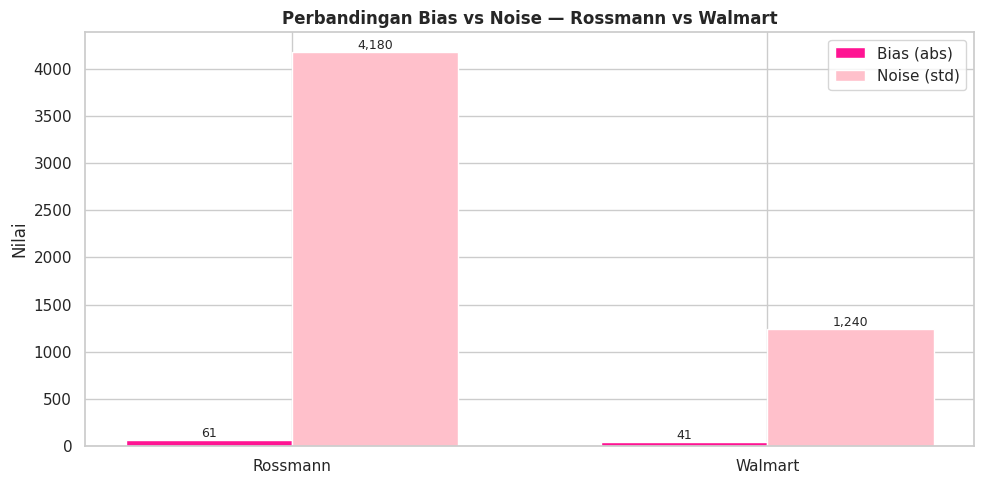

In [65]:
# @title analisis bias vs noise
bias_ross  = np.mean(residual_ross)
noise_ross = np.std(residual_ross)
bias_wal   = np.mean(residual_wal)
noise_wal  = np.std(residual_wal)

# Tabel
tabel_bias_noise = pd.DataFrame({
    'Keterangan'  : ['Bias (Mean Residual)', 'Noise (Std Residual)',
                     'Kesimpulan Bias', 'Kesimpulan Noise'],
    'Rossmann'    : [f'{bias_ross:,.2f}', f'{noise_ross:,.2f}',
                     'Bias Signifikan' if abs(bias_ross) > 100
                     else 'Tidak Ada Bias Signifikan',
                     'Noise Tinggi' if noise_ross > 5000
                     else 'Noise Rendah'],
    'Walmart'     : [f'{bias_wal:,.2f}', f'{noise_wal:,.2f}',
                     'Bias Signifikan' if abs(bias_wal) > 100
                     else 'Tidak Ada Bias Signifikan',
                     'Noise Tinggi' if noise_wal > 5000
                     else 'Noise Rendah']
})

print('TABEL ANALISIS BIAS VS NOISE')
display(tabel_bias_noise)

# Visualisasi
fig, ax = plt.subplots(figsize=(10, 5))
x     = np.arange(2)
width = 0.35

bars1 = ax.bar(x - width/2, [abs(bias_ross), abs(bias_wal)],
               width, label='Bias (abs)', color=['deeppink', 'deeppink'])
bars2 = ax.bar(x + width/2, [noise_ross, noise_wal],
               width, label='Noise (std)', color=['pink', 'pink'])

ax.set_xticks(x)
ax.set_xticklabels(['Rossmann', 'Walmart'])
ax.set_title('Perbandingan Bias vs Noise — Rossmann vs Walmart',
             fontweight='bold')
ax.set_ylabel('Nilai')
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{bar.get_height():,.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

> Sebagai tahapan validasi lanjutan terhadap keandalan algoritma, dilakukan dekomposisi galat (error) ke dalam 2 komponen utama, yaitu Bias (kesalahan sistemik) dan Noise atau variansi (kesalahan acak). Analisis ini bertujuan untuk mendiagnosis apakah ketidakakuratan model murni disebabkan oleh fluktuasi alami data atau adanya kecacatan logika pada model yang membuatnya selalu meleset ke arah tertentu.

> Berdasarkan visualisasi diagram batang dan tabel metrik yang dihasilkan, temuan paling signifikan adalah komponen Bias (direpresentasikan oleh grafik batang berwarna merah muda tua) yang nyaris tidak terlihat karena nilainya yang sangat kecil. Rata-rata residual (mean residual) tercatat hanya sebesar 60,93 untuk model Rossmann dan -40,97 untuk model Walmart. Jika dibandingkan dengan skala total penjualan yang mencapai puluhan hingga ratusan ribu, angka bias ini secara statistik dapat diabaikan (insignificant). Fakta ini mengonfirmasi kesimpulan yang sangat positif: kedua model bersifat sepenuhnya netral, obyektif, dan tidak memiliki kecenderungan bawaan untuk selalu meramalkan nilai terlalu tinggi (overpredict) maupun terlalu rendah (underpredict).

> Di sisi lain, komponen Noise (direpresentasikan oleh grafik batang merah muda terang) yang diukur menggunakan standar deviasi residual mendominasi total keseluruhan galat pada kedua model. Nilai Noise sebesar 4.180,13 pada Rossmann dan 1.240,46 pada Walmart merepresentasikan rentang persebaran fluktuasi acak dari prediksi yang dihasilkan. Meskipun secara nominal angka Noise Rossmann terlihat lebih besar, hal tersebut merupakan konsekuensi logis dari skala agregasi data level toko yang volumenya jauh lebih besar dibandingkan level departemen pada Walmart. Secara proporsional, tingkat Noise pada kedua model ini masih dikategorikan rendah dan berada pada batas toleransi yang wajar untuk peramalan deret waktu.

> Sebagai kesimpulan menyeluruh, evaluasi ini menegaskan bahwa sisa galat yang dihasilkan oleh model Random Forest murni berasal dari dinamika atau noise alami yang wajar terjadi pada data penjualan dunia nyata, bukan akibat dari kegagalan sistemik atau bias struktural pada rancangan model Machine Learning itu sendiri.

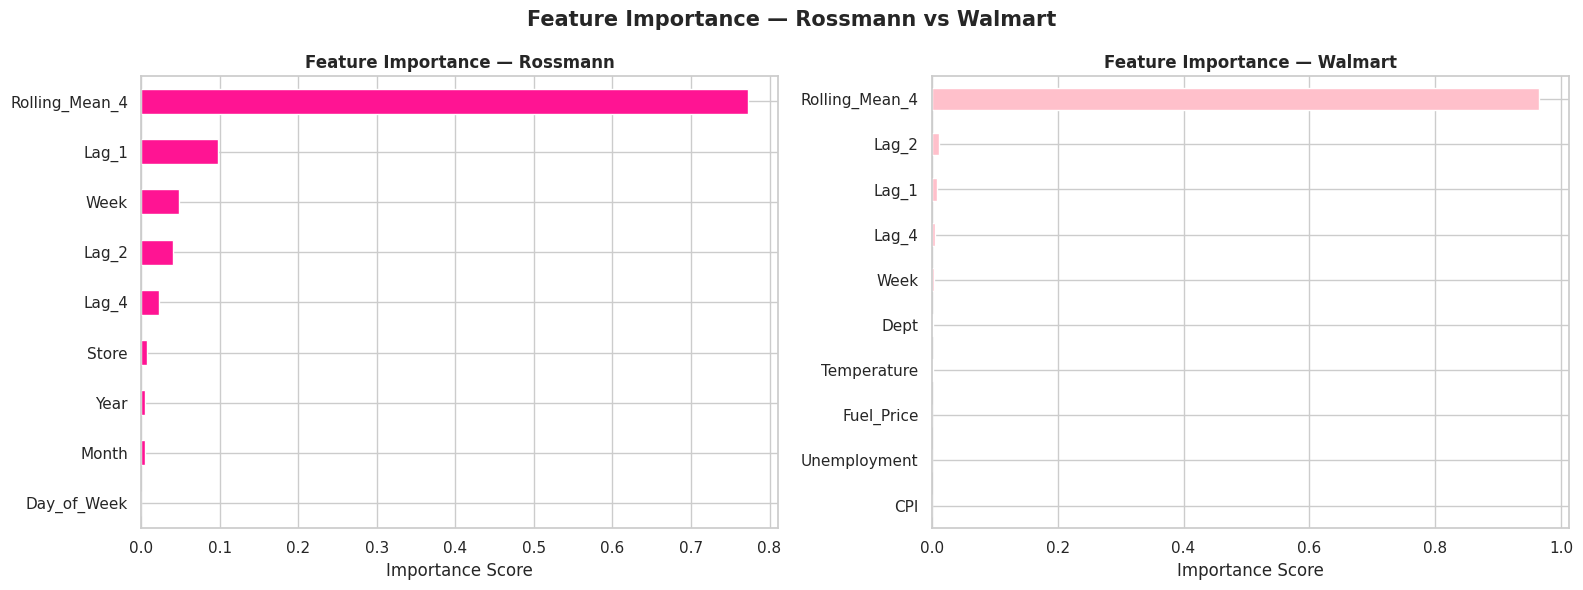


TABEL FEATURE IMPORTANCE — ROSSMANN


,Rank,Fitur Rossmann,Score Rossmann
0,1,Rolling_Mean_4,0.7727
1,2,Lag_1,0.0976
2,3,Week,0.0480
3,4,Lag_2,0.0410
4,5,Lag_4,0.0228
5,6,Store,0.0078
6,7,Year,0.0053
7,8,Month,0.0048
8,9,Day_of_Week,0.0000



TABEL FEATURE IMPORTANCE — WALMART


,Fitur Walmart,Score Walmart
0,Rolling_Mean_4,0.9647
1,Lag_2,0.0114
2,Lag_1,0.0079
3,Lag_4,0.0046
4,Week,0.0032
5,Dept,0.0012
6,Temperature,0.0011
7,Fuel_Price,0.0009
8,Unemployment,0.0008
9,CPI,0.0008


In [68]:
# @title feature importance
imp_ross = pd.Series(model_ross.feature_importances_,
                     index=fitur_ross).sort_values(ascending=False)
imp_wal  = pd.Series(model_wal.feature_importances_,
                     index=fitur_wal).sort_values(ascending=False)

# Visualisasi
top_n = 10
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

imp_ross.sort_values().plot(kind='barh', ax=axes[0], color='deeppink')
axes[0].set_title('Feature Importance — Rossmann', fontweight='bold')
axes[0].set_xlabel('Importance Score')

imp_wal.head(top_n).sort_values().plot(kind='barh', ax=axes[1], color='pink')
axes[1].set_title('Feature Importance — Walmart', fontweight='bold')
axes[1].set_xlabel('Importance Score')

plt.suptitle('Feature Importance — Rossmann vs Walmart',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabel feature importance
tabel_imp = pd.DataFrame({
    'Rank'               : range(1, len(fitur_ross) + 1),
    'Fitur Rossmann'     : imp_ross.index.tolist(),
    'Score Rossmann'     : [f'{v:.4f}' for v in imp_ross.values],
})

# Walmart bisa punya fitur lebih banyak (ada Dept)
tabel_imp_wal = pd.DataFrame({
    'Fitur Walmart'  : imp_wal.index.tolist(),
    'Score Walmart'  : [f'{v:.4f}' for v in imp_wal.values],
})

print('\nTABEL FEATURE IMPORTANCE — ROSSMANN')
display(tabel_imp)
print('\nTABEL FEATURE IMPORTANCE — WALMART')
display(tabel_imp_wal)

> Analisis Feature Importance dilakukan untuk mengidentifikasi variabel mana yang memberikan kontribusi terbesar terhadap daya prediksi algoritma. Melalui visualisasi diagram batang dan tabel ringkasan, terlihat sebuah pola kesamaan yang sangat signifikan antara model Rossmann dan Walmart.

> Fitur rekayasa rata-rata pergerakan atau Rolling_Mean_4 (representasi rata-rata penjualan 4 minggu terakhir) tampil sebagai prediktor yang mendominasi secara absolut. Pada model Rossmann, fitur ini menyumbang bobot kepentingan sebesar 0,7727, sementara pada model Walmart dominasinya melonjak sangat tajam hingga mencapai angka 0,9647. Posisi berikutnya secara konsisten diisi oleh variabel riwayat observasi masa lalu (Lag_1 dan Lag_2), meskipun dengan selisih skor yang terpaut jauh dari fitur utamanya.

> Sebuah temuan analitis yang krusial terlihat pada hasil dataset Walmart. Rangkaian variabel prediktor eksternal, baik itu indikator cuaca (Temperature) maupun metrik makroekonomi (Fuel_Price, Unemployment, dan CPI), terbukti memberikan dampak prediktif yang sangat minim (dengan skor keseluruhan di bawah 0,002). Secara garis besar, evaluasi ini memberikan kesimpulan tegas bahwa dalam peramalan deret waktu ritel, rekaman momentum penjualan historis jangka pendek merupakan indikator yang jauh lebih esensial dan memiliki daya presisi lebih tinggi dibandingkan dengan pengaruh faktor-faktor eksternal.

# **Kesimpulan**



---

> Berdasarkan hasil penelitian dan evaluasi pemodelan Machine Learning menggunakan algoritma Random Forest Regressor pada dataset ritel Rossmann dan Walmart, dapat disimpulkan bahwa pendekatan prediktif ini memiliki tingkat keandalan yang sangat memuaskan. Hal ini dibuktikan secara kuantitatif melalui perolehan tingkat kesalahan relatif (MAPE) yang berhasil ditekan secara konsisten di bawah ambang batas 10%, yakni sebesar 7,25% untuk model Rossmann dan 8,30% untuk model Walmart.

> Analisis residual turut mengonfirmasi objektivitas algoritma, di mana galat sistemik (bias) berada pada level yang nyaris nol, sehingga penyimpangan peramalan yang terjadi murni diakibatkan oleh fluktuasi acak (noise) alami dari data penjualan. Selanjutnya, tinjauan terhadap signifikansi fitur (Feature Importance) secara tegas menyoroti bahwa riwayat momentum penjualan jangka pendek, khususnya rata-rata pergerakan empat minggu terakhir (Rolling_Mean_4), merupakan prediktor yang paling dominan dan esensial. Sebaliknya, indikator makroekonomi maupun eksternal cuaca terbukti tidak memberikan dampak yang signifikan terhadap dinamika penjualan mingguan. Meskipun performa pemodelan secara makro tergolong tangguh, evaluasi granular mengidentifikasi beberapa limitasi struktural pada model Rossmann, antara lain kegagalannya dalam mendeteksi hari non-operasional toko, sensitivitas galat yang melonjak pada musim liburan akhir tahun, serta keberadaan pencilan (outlier) karakteristik yang sangat ekstrem pada Toko 1114.

> Oleh karena itu, guna mencapai optimasi peramalan yang lebih presisi pada penelitian lanjutan, sangat direkomendasikan untuk mengintegrasikan variabel penanda operasional secara eksplisit—seperti status operasional toko dan indikator kalender promosi—serta menerapkan pendekatan pemodelan terpisah (custom modeling) bagi cabang-cabang yang memiliki anomali pola penjualan historis.